# Change-Target Modeling Track

This notebook tests a second-stage modeling direction for the CAST+ conflict forecasting project: predicting **month-to-month change in conflict intensity** instead of only predicting raw event counts.

The original project forecasts monthly conflict event counts at the admin-1 level. This notebook keeps that project structure, but redesigns the target so the model focuses on escalation and de-escalation dynamics.

## Main Question

Can we improve conflict forecasting by predicting change?

Instead of modeling the raw count directly:

`y_t`

this notebook models:

`delta_y = y_t - y_(t-1)`

A positive delta means conflict increased from the previous month.  
A negative delta means conflict decreased from the previous month.  
A zero delta means the conflict count stayed the same.

## Targets

The notebook creates signed change targets for:

- Battles
- Explosions/Remote violence
- Violence against civilians

These are represented as:

- `delta_battles`
- `delta_remote_violence`
- `delta_vac`

## Modeling Setup

Because delta targets can be negative, count-based objectives such as Poisson are not appropriate here.

This notebook compares models that can handle signed regression targets:

- RandomForestRegressor
- LightGBM with standard regression objective
- CatBoostRegressor
- HistGradientBoostingRegressor

The main baseline comparison is against RandomForest, since RandomForest is the original basic model.

## Feature Logic

The feature set keeps the useful conflict, neighbor, time, religion, World Bank, risk, and engineered features from the processed dataset.(lagged holiday features are excluded)

This is because holidays are calendar-known features, not historical signals like conflict lags.

## Evaluation

The notebook uses the same basic chronological split logic as the original project:

- last 6 months as test period
- earlier months as training period
- results separated by target

Evaluation uses:
- MAE
- RMSE
- model win counts by region and target
- feature importance (temporary test)
- prediction bias

In [2]:
from pathlib import Path
import sys
import warnings
import os
from joblib import parallel_backend

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from lightgbm import LGBMRegressor

warnings.filterwarnings("ignore")
os.environ["PYTHONWARNINGS"] = "ignore"
os.environ["LOKY_MAX_CPU_COUNT"] = "1"

REPO_ROOT = Path(r'C:\Users\Rosa Daneshmandnia\predicting-global-conflict')
if str(REPO_ROOT / 'forecast_model') not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / 'forecast_model'))

RANDOM_STATE = 42

In [3]:
model_data = pd.read_csv(r"C:\Users\Rosa Daneshmandnia\predicting-global-conflict\data\processed\model_data.csv")

model_data = model_data.set_index(['matched_admin1_id', 'month_year'])

model_data = model_data.sort_index()

print(f'Loaded: {model_data.shape[0]:,} rows x {model_data.shape[1]} cols')
model_data.info()
model_data.describe()

Loaded: 278,820 rows x 100 cols
<class 'pandas.DataFrame'>
MultiIndex: 278820 entries, ('ABW - Aruba', '2018-01') to (nan, '2025-06')
Data columns (total 100 columns):
 #   Column                                       Non-Null Count   Dtype  
---  ------                                       --------------   -----  
 0   Battles (t-1)                                275633 non-null  float64
 1   Explosions/Remote violence (t-1)             275633 non-null  float64
 2   Protests (t-1)                               275633 non-null  float64
 3   Riots (t-1)                                  275633 non-null  float64
 4   Strategic developments (t-1)                 275633 non-null  float64
 5   Violence against civilians (t-1)             275633 non-null  float64
 6   Excessive force against protesters (t-1)     275633 non-null  float64
 7   Agreement (t-1)                              275633 non-null  float64
 8   Explosions/Remote violence_neighbours (t-1)  275633 non-null  float64
 9   St

,Battles (t-1),Explosions/Remote violence (t-1),Protests (t-1),Riots (t-1),Strategic developments (t-1),Violence against civilians (t-1),Excessive force against protesters (t-1),Agreement (t-1),Explosions/Remote violence_neighbours (t-1),Strategic developments_neighbours (t-1),...,risk_military_coup,risk_natural_disaster,risk_political_assassination,risk_contested_election (t-1),risk_crop_failure (t-1),risk_economic_concern (t-1),risk_ethnic_tension (t-1),risk_military_coup (t-1),risk_natural_disaster (t-1),risk_political_assassination (t-1)
count,275633.000000,275633.000000,275633.000000,275633.000000,275633.000000,275633.000000,275633.000000,275633.000000,275633.000000,275633.000000,...,278820.000000,278820.000000,278820.000000,278820.000000,278820.000000,278820.000000,278820.000000,278820.000000,278820.000000,278820.000000
mean,1.238741,1.409740,3.471569,0.481844,0.565821,0.856490,0.013707,0.009556,6.946316,2.895836,...,0.069260,0.350133,0.105297,0.099577,0.380432,0.247174,0.138634,0.068273,0.342364,0.099778
std,13.849694,23.869244,13.955840,5.851017,3.813787,4.079164,0.431490,0.165491,72.337224,12.018981,...,0.333235,1.146762,0.844635,0.489615,1.042766,0.675020,0.531955,0.331815,1.130166,0.831644
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1664.000000,1773.000000,715.000000,862.000000,286.000000,234.000000,119.000000,29.000000,3961.000000,464.000000,...,16.000000,37.000000,26.000000,12.000000,19.000000,31.000000,23.000000,16.000000,37.000000,26.000000


In [4]:
RAW_TARGETS = [
    'Battles',
    'Explosions/Remote violence',
    'Violence against civilians',
]

DELTA_TARGET_MAP = {
    'Battles': 'delta_battles',
    'Explosions/Remote violence': 'delta_remote_violence',
    'Violence against civilians': 'delta_vac',
}

DELTA_TARGETS = []

for target in RAW_TARGETS:
    lag_col = f'{target} (t-1)'
    delta_col = DELTA_TARGET_MAP[target]

    if lag_col in model_data.columns:
        model_data[delta_col] = model_data[target] - model_data[lag_col]
        DELTA_TARGETS.append(delta_col)

delta_summary = model_data[DELTA_TARGETS].agg(['mean', 'std', 'min', 'max']).T.round(3)
delta_summary['zero_share'] = (model_data[DELTA_TARGETS] == 0).mean().round(3)
delta_summary['negative_share'] = (model_data[DELTA_TARGETS] < 0).mean().round(3)
delta_summary['positive_share'] = (model_data[DELTA_TARGETS] > 0).mean().round(3)

delta_summary

,mean,std,min,max,zero_share,negative_share,positive_share
delta_battles,-0.006,4.142,-582.0,385.0,0.857,0.066,0.065
delta_remote_violence,0.004,7.362,-1004.0,879.0,0.922,0.033,0.033
delta_vac,-0.001,1.988,-149.0,188.0,0.799,0.095,0.094


In [5]:
#same as raw notebook
all_cols = model_data.columns.tolist()

conflict_lag_features = [c for c in all_cols if c.endswith('(t-1)') and c.split(' (t-1)')[0] in [
    'Battles', 'Explosions/Remote violence', 'Protests', 'Riots',
    'Strategic developments', 'Violence against civilians',
    'Excessive force against protesters', 'Agreement'
]]

neighbor_features = [c for c in all_cols if '_neighbours (t-1)' in c]

time_features = [
    c for c in all_cols
    if c == 'linear_month_trend' or c == 'year' or c.startswith('month_') or c.startswith('quarter_')
]

worldbank_lag_features = [c for c in [
    'inflation (t-1)', 'youth_unemployment (t-1)', 'income_inequality (t-1)', 'income_level_code (t-1)'
] if c in all_cols]

religion_features = [c for c in [
    'majority_religion', 'majority_pct', 'minority1_religion', 'minority1_pct',
    'minority2_religion', 'minority2_pct', 'nonreligpct'
] if c in all_cols]

holiday_current_features = [c for c in all_cols if 'holiday_count' in c and '(t-1)' not in c]

holiday_interaction_current = [c for c in [
    'weighted_holidays_majority', 'weighted_holidays_minority1', 'weighted_holidays_minority2',
    'minority_tension_minority1', 'minority_tension_minority2', 'minority_tension_total',
    'total_religious_mobilization'
] if c in all_cols]

wbd_engineered_features = [c for c in [
    'structural_vulnerability', 'inflation_shock', 'shock_vulnerability', 'capacity_adjusted_risk',
    'inflation_change', 'high_inequality_flag', 'inflation_shock_poor',
    'conflict_momentum', 'violence_escalation', 'macro_conflict_pressure'
] if c in all_cols]

risk_features = [c for c in all_cols if c.startswith('risk_')]

excluded_holiday_lags = [c for c in all_cols if 'holiday_count' in c and '(t-1)' in c]

excluded_holiday_interaction_lags = [
    c for c in all_cols
    if '(t-1)' in c and any(k in c for k in ['weighted_holidays', 'minority_tension', 'mobilization'])
]

baseline_feature_cols = list(dict.fromkeys(
    conflict_lag_features
    + neighbor_features
    + time_features
    + worldbank_lag_features
    + religion_features
    + holiday_current_features
    + holiday_interaction_current
    + wbd_engineered_features
    + risk_features
))

len(baseline_feature_cols)

80

In [6]:
def split_region_data(region_data, test_horizon=6):
    train = region_data.iloc[:-test_horizon]
    test = region_data.iloc[-test_horizon:]
    return train, test


def encode_categoricals(X_train, X_test):
    X_train = X_train.copy()
    X_test = X_test.copy()

    cat_cols = X_train.select_dtypes(
        include=["object", "category", "string"]
    ).columns.tolist()

    for col in cat_cols:
        le = LabelEncoder()

        X_train[col] = X_train[col].fillna("__MISSING__").astype(str)
        X_test[col] = X_test[col].fillna("__MISSING__").astype(str)

        X_train[col] = le.fit_transform(X_train[col])

        known = set(le.classes_)
        X_test[col] = X_test[col].map(
            lambda x: le.transform([x])[0] if x in known else -1
        )

    return X_train, X_test


def prepare_rf_inputs(train_df, test_df, feature_cols):
    X_train = train_df[feature_cols].copy()
    X_test = test_df[feature_cols].copy()

    num_bool_cols = X_train.select_dtypes(include=["number", "bool"]).columns.tolist()
    X_train[num_bool_cols] = X_train[num_bool_cols].fillna(0)
    X_test[num_bool_cols] = X_test[num_bool_cols].fillna(0)

    X_train, X_test = encode_categoricals(X_train, X_test)
    return X_train, X_test


def prepare_catboost_native_inputs(train_df, test_df, feature_cols):
    X_train = train_df[feature_cols].copy()
    X_test = test_df[feature_cols].copy()

    bool_cols = X_train.select_dtypes(include=["bool"]).columns.tolist()
    for col in bool_cols:
        X_train[col] = X_train[col].astype(int)
        X_test[col] = X_test[col].astype(int)

    cat_cols = X_train.select_dtypes(
        include=["object", "category", "string"]
    ).columns.tolist()

    for col in cat_cols:
        X_train[col] = X_train[col].fillna("__MISSING__").astype(str)
        X_test[col] = X_test[col].fillna("__MISSING__").astype(str)

    return X_train, X_test, cat_cols


def prepare_catboost_encoded_inputs(train_df, test_df, feature_cols):
    X_train = train_df[feature_cols].copy()
    X_test = test_df[feature_cols].copy()

    bool_cols = X_train.select_dtypes(include=["bool"]).columns.tolist()
    for col in bool_cols:
        X_train[col] = X_train[col].astype(int)
        X_test[col] = X_test[col].astype(int)

    X_train, X_test = encode_categoricals(X_train, X_test)
    return X_train, X_test


CATBOOST_MODE = "native"  # or "encoded"


def prepare_catboost_inputs(train_df, test_df, feature_cols, mode=CATBOOST_MODE):
    if mode == "native":
        return prepare_catboost_native_inputs(train_df, test_df, feature_cols)
    elif mode == "encoded":
        X_train, X_test = prepare_catboost_encoded_inputs(train_df, test_df, feature_cols)
        return X_train, X_test, None
    else:
        raise ValueError("mode must be 'native' or 'encoded'")


def prepare_lgbm_inputs(train_df, test_df, feature_cols):
    X_train = train_df[feature_cols].copy()
    X_test = test_df[feature_cols].copy()

    bool_cols = X_train.select_dtypes(include=["bool"]).columns.tolist()
    for col in bool_cols:
        X_train[col] = X_train[col].astype(int)
        X_test[col] = X_test[col].astype(int)

    X_train, X_test = encode_categoricals(X_train, X_test)
    return X_train, X_test


def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

In [7]:
MODELS = {
    'RandomForest': RandomForestRegressor(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
    'LightGBM_Regression': LGBMRegressor(
        objective='regression',
        n_estimators=500,
        learning_rate=0.05,
        max_depth=4,
        random_state=RANDOM_STATE,
        verbose=-1,
    ),
    'CatBoost': CatBoostRegressor(
        iterations=500,
        learning_rate=0.05,
        depth=4,
        random_seed=RANDOM_STATE,
        verbose=0,
    ),
    'HistGradientBoosting': HistGradientBoostingRegressor(
        max_iter=500,
        learning_rate=0.05,
        max_depth=4,
        random_state=RANDOM_STATE,
    ),
}

MODELS

{'RandomForest': RandomForestRegressor(n_estimators=300, n_jobs=1, random_state=42),
 'LightGBM_Regression': LGBMRegressor(learning_rate=0.05, max_depth=4, n_estimators=500,
               objective='regression', random_state=42, verbose=-1),
 'CatBoost': CatBoostRegressor(depth=4, iterations=500, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=0),
 'HistGradientBoosting': HistGradientBoostingRegressor(learning_rate=0.05, max_depth=4, max_iter=500,
                               random_state=42)}

In [8]:
all_regions = model_data.index.get_level_values('matched_admin1_id').unique()

VALID_REGIONS = []
skipped_too_short = []
skipped_all_zero = []

for region in all_regions:
    region_data = model_data.loc[region].sort_index()

    if len(region_data) < 12:
        skipped_too_short.append(region)
        continue

    train_data, test_data = split_region_data(region_data)

    if train_data[DELTA_TARGETS].nunique().max() <= 1:
        skipped_all_zero.append(region)
        continue

    VALID_REGIONS.append(region)

print(f"Valid regions: {len(VALID_REGIONS)}")
print(f"Skipped (<12 months): {len(skipped_too_short)}")
print(f"Skipped (no variation in delta targets): {len(skipped_all_zero)}")

VALID_REGIONS[:10]

Valid regions: 2205
Skipped (<12 months): 0
Skipped (no variation in delta targets): 893


['AFG - Badakhshan',
 'AFG - Badghis',
 'AFG - Baghlan',
 'AFG - Balkh',
 'AFG - Bamyan',
 'AFG - Daykundi',
 'AFG - Farah',
 'AFG - Faryab',
 'AFG - Ghazni',
 'AFG - Ghor']

In [9]:
RUN_REGIONS = VALID_REGIONS
RUN_TARGETS = DELTA_TARGETS

results = []
feature_importances = {}

with parallel_backend("sequential"):
    for region in RUN_REGIONS:
        region_data = model_data.loc[region].sort_index()
        train_data, test_data = split_region_data(region_data)
        weights_full = train_data['importance_weight'] if 'importance_weight' in train_data.columns else None
    
        for target in RUN_TARGETS:
            train_pair = train_data[baseline_feature_cols + [target]].copy()
            test_pair = test_data[baseline_feature_cols + [target]].copy()
    
            train_pair = train_pair[train_pair[target].notna()]
            test_pair = test_pair[test_pair[target].notna()]
    
            if len(train_pair) == 0 or len(test_pair) == 0:
                continue
    
            y_train = train_pair[target]
            y_test = test_pair[target]
    
            if y_train.nunique() <= 1:
                continue

            weights = None
            if weights_full is not None:
                weights = weights_full.loc[train_pair.index]
    
            X_train_rf, X_test_rf = prepare_rf_inputs(train_pair, test_pair, baseline_feature_cols)
            X_train_lgbm, X_test_lgbm = prepare_lgbm_inputs(train_pair, test_pair, baseline_feature_cols)
            X_train_hgb, X_test_hgb = prepare_rf_inputs(train_pair, test_pair, baseline_feature_cols)
            X_train_cb, X_test_cb, cat_cols_cb = prepare_catboost_inputs(
                train_pair, test_pair, baseline_feature_cols
            )
    

            for model_name, model in MODELS.items():
                try:
                    if model_name == 'RandomForest':
                        X_tr, X_te = X_train_rf, X_test_rf
                        fit_kwargs = {}
                        if weights is not None:
                            fit_kwargs['sample_weight'] = weights.values
    
                    elif model_name == 'LightGBM_Regression':
                        X_tr, X_te = X_train_lgbm, X_test_lgbm
                        fit_kwargs = {}
                        if weights is not None:
                            fit_kwargs['sample_weight'] = weights.values

                    elif model_name == 'HistGradientBoosting':
                        X_tr, X_te = X_train_hgb, X_test_hgb
                        fit_kwargs = {}
    
                    else:
                        X_tr, X_te = X_train_cb, X_test_cb
                        fit_kwargs = {}
                        if cat_cols_cb is not None:
                            fit_kwargs['cat_features'] = cat_cols_cb
                        if weights is not None:
                            fit_kwargs['sample_weight'] = weights.values
    
                    model.fit(X_tr, y_train, **fit_kwargs)
                    y_pred = model.predict(X_te)
    
                    results.append({
                        'region': region,
                        'target': target,
                        'model': model_name,
                        'mae': mean_absolute_error(y_test, y_pred),
                        'rmse': rmse(y_test, y_pred),
                        'mean_actual': y_test.mean(),
                        'mean_pred': float(np.mean(y_pred)),
                    })
    
                    if hasattr(model, 'feature_importances_'):
                        feature_importances[(model_name, region, target)] = pd.Series(
                            model.feature_importances_,
                            index=baseline_feature_cols,
                        )
    
                except Exception as exc:
                    print(f'ERROR | {model_name} | {region} | {target}: {exc}')

results_df = pd.DataFrame(results)
print(f"Rows collected: {len(results_df)}")
results_df

KeyboardInterrupt: 

In [11]:
summary = (
    results_df
    .groupby(['model', 'target'])[['mae', 'rmse']]
    .mean()
    .round(3)
    .sort_index()
)

summary

mae   rmse
model                target                             
CatBoost             delta_battles          1.607  2.030
                     delta_remote_violence  3.011  3.634
                     delta_vac              0.886  1.096
HistGradientBoosting delta_battles          1.858  2.294
                     delta_remote_violence  3.235  3.995
                     delta_vac              0.972  1.184
LightGBM_Regression  delta_battles          1.878  2.326
                     delta_remote_violence  3.649  4.380
                     delta_vac              1.036  1.259
RandomForest         delta_battles          1.678  2.088
                     delta_remote_violence  3.104  3.730
                     delta_vac              0.908  1.111

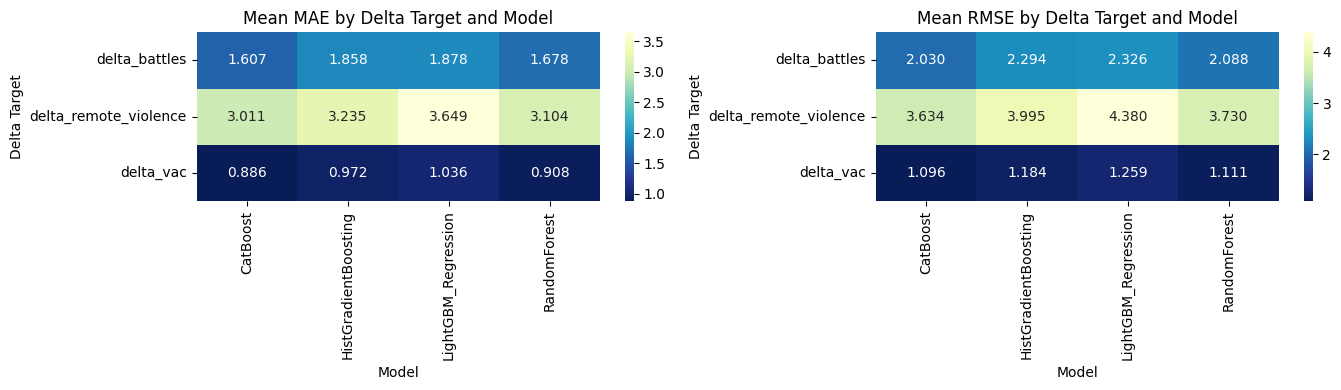

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, metric in zip(axes, ['mae', 'rmse']):
    heatmap_data = results_df.pivot_table(
        index='target',
        columns='model',
        values=metric,
        aggfunc='mean'
    )

    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt='.3f',
        cmap='YlGnBu_r',
        ax=ax
    )

    ax.set_title(f'Mean {metric.upper()} by Delta Target and Model')
    ax.set_xlabel('Model')
    ax.set_ylabel('Delta Target')

plt.tight_layout()
plt.show()

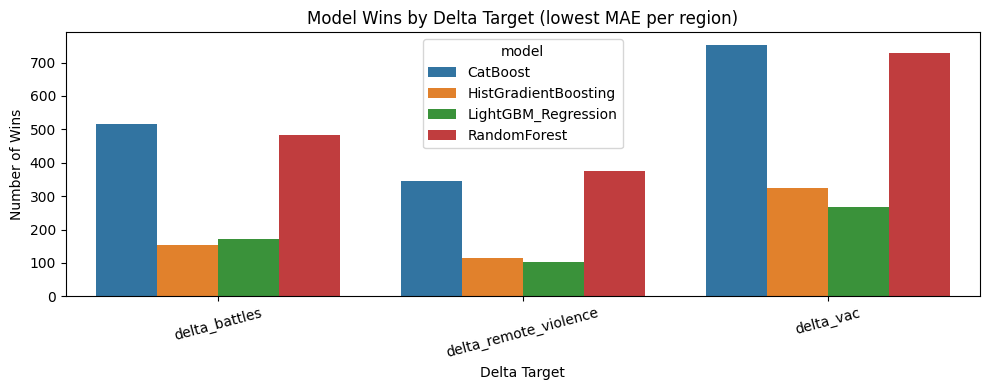

model,CatBoost,HistGradientBoosting,LightGBM_Regression,RandomForest
target,,,,
delta_battles,517,153,171,484
delta_remote_violence,346,115,102,376
delta_vac,753,324,268,730


In [13]:
wins = (
    results_df
    .loc[results_df.groupby(['region', 'target'])['mae'].idxmin()]
    .groupby(['target', 'model'])
    .size()
    .reset_index(name='wins')
)

plt.figure(figsize=(10, 4))
sns.barplot(
    data=wins,
    x='target',
    y='wins',
    hue='model'
)

plt.title('Model Wins by Delta Target (lowest MAE per region)')
plt.xlabel('Delta Target')
plt.ylabel('Number of Wins')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

wins.pivot(index='target', columns='model', values='wins').fillna(0).astype(int)

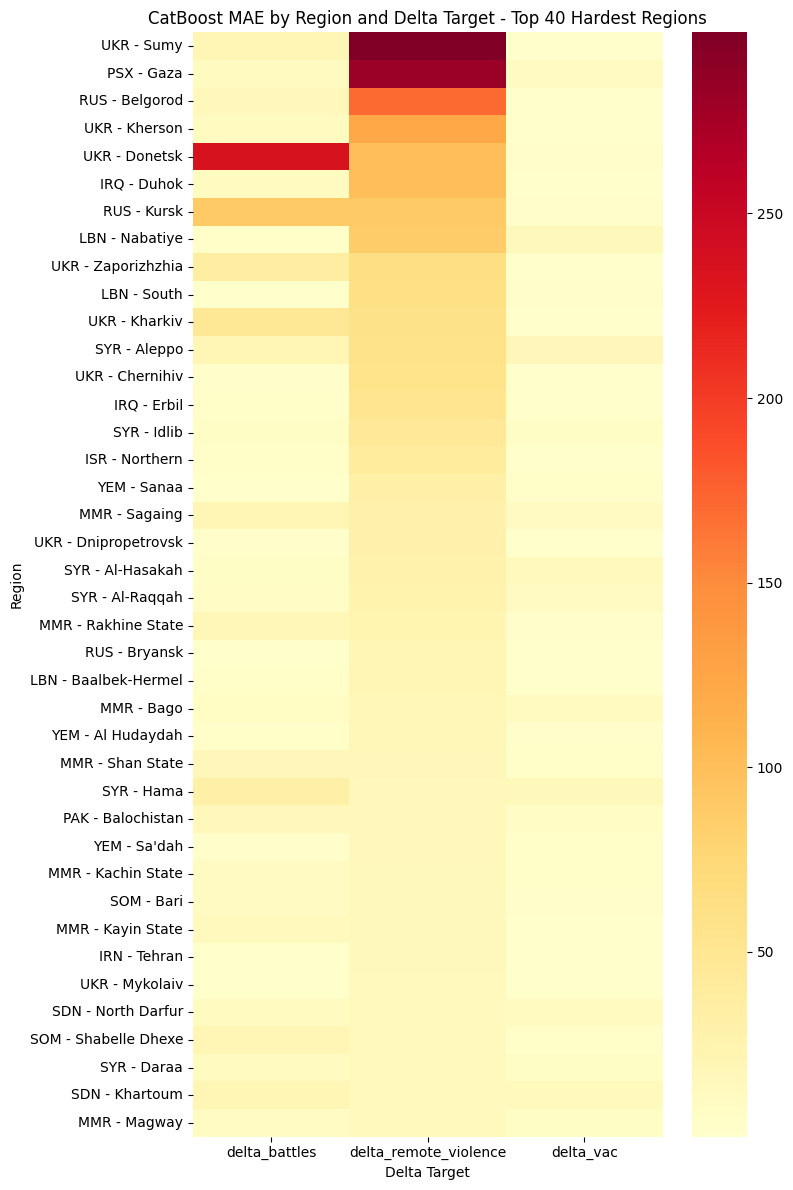

In [14]:
catboost_region_mae = (
    results_df[results_df['model'] == 'CatBoost']
    .pivot_table(
        index='region',
        columns='target',
        values='mae',
        aggfunc='mean'
    )
    .sort_values(by='delta_remote_violence', ascending=False)
    .head(40)
)

plt.figure(figsize=(8, 12))
sns.heatmap(
    catboost_region_mae,
    annot=False,
    cmap='YlOrRd'
)

plt.title('CatBoost MAE by Region and Delta Target - Top 40 Hardest Regions')
plt.xlabel('Delta Target')
plt.ylabel('Region')
plt.tight_layout()
plt.show()

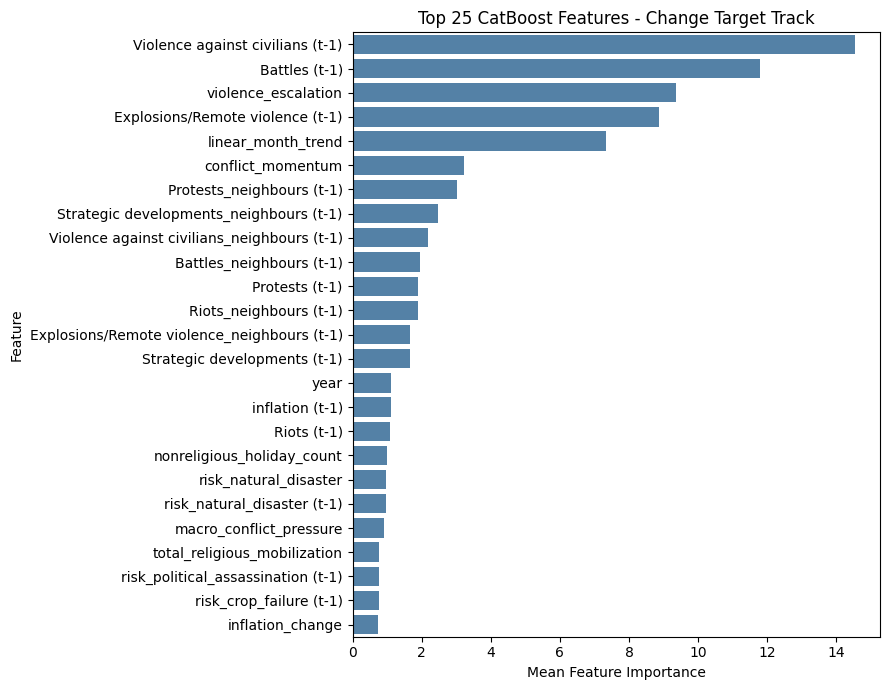

In [15]:
catboost_fi = [
    fi for (model_name, region, target), fi in feature_importances.items()
    if model_name == 'CatBoost'
]

if catboost_fi:
    catboost_fi_mean = (
        pd.concat(catboost_fi, axis=1)
        .mean(axis=1)
        .sort_values(ascending=False)
        .head(25)
    )

    plt.figure(figsize=(9, 7))
    sns.barplot(
        x=catboost_fi_mean.values,
        y=catboost_fi_mean.index,
        color='steelblue'
    )

    plt.title('Top 25 CatBoost Features - Change Target Track')
    plt.xlabel('Mean Feature Importance')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()
else:
    print('No CatBoost feature importances collected.')

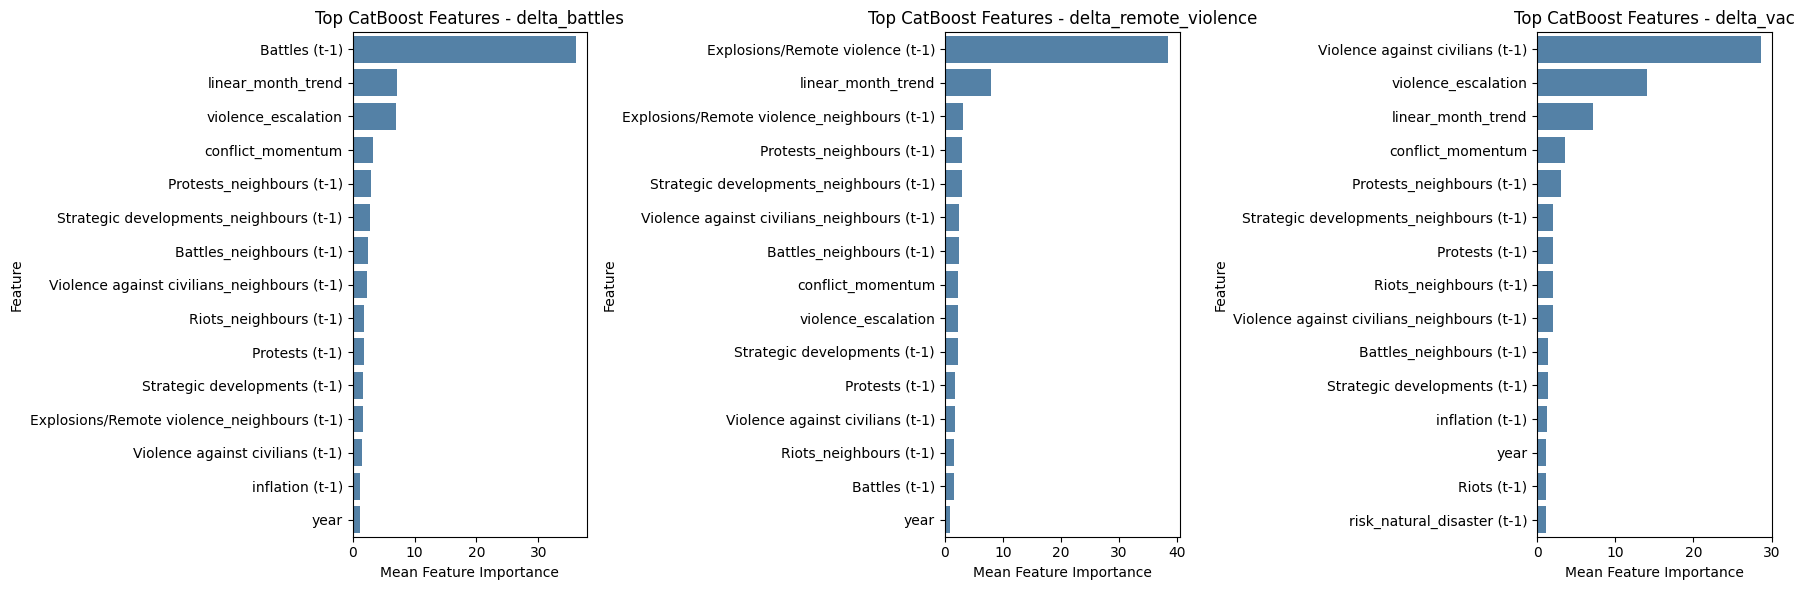

In [16]:
catboost_fi_by_target = {}

for target in DELTA_TARGETS:
    fi_list = [
        fi for (model_name, region, fi_target), fi in feature_importances.items()
        if model_name == 'CatBoost' and fi_target == target
    ]

    if fi_list:
        catboost_fi_by_target[target] = (
            pd.concat(fi_list, axis=1)
            .mean(axis=1)
            .sort_values(ascending=False)
            .head(15)
        )

fig, axes = plt.subplots(
    1,
    len(catboost_fi_by_target),
    figsize=(6 * len(catboost_fi_by_target), 6),
    sharex=False
)

if len(catboost_fi_by_target) == 1:
    axes = [axes]

for ax, (target, fi_values) in zip(axes, catboost_fi_by_target.items()):
    sns.barplot(
        x=fi_values.values,
        y=fi_values.index,
        ax=ax,
        color='steelblue'
    )

    ax.set_title(f'Top CatBoost Features - {target}')
    ax.set_xlabel('Mean Feature Importance')
    ax.set_ylabel('Feature')

plt.tight_layout()
plt.show()

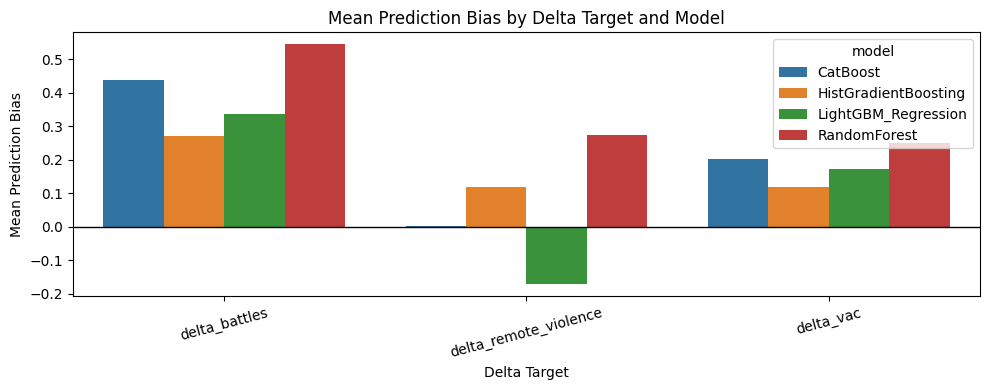

,target,model,bias
0,delta_battles,CatBoost,0.439
1,delta_battles,HistGradientBoosting,0.272
2,delta_battles,LightGBM_Regression,0.338
3,delta_battles,RandomForest,0.545
4,delta_remote_violence,CatBoost,0.003
5,delta_remote_violence,HistGradientBoosting,0.120
6,delta_remote_violence,LightGBM_Regression,-0.172
7,delta_remote_violence,RandomForest,0.274
8,delta_vac,CatBoost,0.202
9,delta_vac,HistGradientBoosting,0.120


In [17]:
bias_summary = results_df.copy()
bias_summary['bias'] = bias_summary['mean_pred'] - bias_summary['mean_actual']

bias_plot = (
    bias_summary
    .groupby(['target', 'model'])['bias']
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 4))
sns.barplot(
    data=bias_plot,
    x='target',
    y='bias',
    hue='model'
)

plt.axhline(0, color='black', linewidth=1)
plt.title('Mean Prediction Bias by Delta Target and Model')
plt.xlabel('Delta Target')
plt.ylabel('Mean Prediction Bias')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

bias_plot.round(3)

In [18]:
country_hierarchy_data = model_data.reset_index().copy()

country_hierarchy_data['iso3'] = country_hierarchy_data['matched_admin1_id'].str.split(' - ').str[0]

country_targets = {
    'Battles': 'country_battles_excl (t-1)',
    'Explosions/Remote violence': 'country_remote_excl (t-1)',
    'Violence against civilians': 'country_vac_excl (t-1)',
}

for target, new_col in country_targets.items():
    country_month_total = (
        country_hierarchy_data
        .groupby(['iso3', 'month_year'])[target]
        .transform('sum')
    )

    country_hierarchy_data[new_col] = country_month_total - country_hierarchy_data[target]

country_hierarchy_data['country_total_excl (t-1)'] = (
    country_hierarchy_data[list(country_targets.values())].sum(axis=1)
)

country_hierarchy_cols = list(country_targets.values()) + ['country_total_excl (t-1)']

country_hierarchy_data = (
    country_hierarchy_data
    .sort_values(['matched_admin1_id', 'month_year'])
)

for col in country_hierarchy_cols:
    country_hierarchy_data[col] = (
        country_hierarchy_data
        .groupby('matched_admin1_id')[col]
        .shift(1)
    )

model_data_hierarchy = (
    country_hierarchy_data
    .set_index(['matched_admin1_id', 'month_year'])
    .sort_index()
)

country_hierarchy_cols


['country_battles_excl (t-1)',
 'country_remote_excl (t-1)',
 'country_vac_excl (t-1)',
 'country_total_excl (t-1)']

In [10]:
hierarchy_feature_cols = baseline_feature_cols + country_hierarchy_cols

RUN_REGIONS = VALID_REGIONS
RUN_TARGETS = DELTA_TARGETS

hierarchy_results = []

for region in RUN_REGIONS:
    region_data = model_data_hierarchy.loc[region].sort_index()
    train_data, test_data = split_region_data(region_data)
    weights_full = train_data['importance_weight'] if 'importance_weight' in train_data.columns else None

    for target in RUN_TARGETS:
        train_pair = train_data[hierarchy_feature_cols + [target]].copy()
        test_pair = test_data[hierarchy_feature_cols + [target]].copy()

        train_pair = train_pair[train_pair[target].notna()]
        test_pair = test_pair[test_pair[target].notna()]

        if len(train_pair) == 0 or len(test_pair) == 0:
            continue

        y_train = train_pair[target]
        y_test = test_pair[target]

        if y_train.nunique() <= 1:
            continue

        weights = None
        if weights_full is not None:
            weights = weights_full.loc[train_pair.index]

        X_train_rf, X_test_rf = prepare_rf_inputs(
            train_pair, test_pair, hierarchy_feature_cols
        )

        X_train_cb, X_test_cb, cat_cols_cb = prepare_catboost_inputs(
            train_pair, test_pair, hierarchy_feature_cols
        )

        model_specs = {
            'RandomForest_Hierarchy': RandomForestRegressor(
                n_estimators=300,
                random_state=RANDOM_STATE,
                n_jobs=1,
            ),
            'CatBoost_Hierarchy': CatBoostRegressor(
                iterations=500,
                learning_rate=0.05,
                depth=4,
                random_seed=RANDOM_STATE,
                verbose=0,
            ),
        }

        for model_name, model in model_specs.items():
            if model_name == 'RandomForest_Hierarchy':
                X_tr, X_te = X_train_rf, X_test_rf
                fit_kwargs = {}
                if weights is not None:
                    fit_kwargs['sample_weight'] = weights.values

            else:
                X_tr, X_te = X_train_cb, X_test_cb
                fit_kwargs = {}
                if cat_cols_cb is not None:
                    fit_kwargs['cat_features'] = cat_cols_cb
                if weights is not None:
                    fit_kwargs['sample_weight'] = weights.values

            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                model.fit(X_tr, y_train, **fit_kwargs)

            y_pred = model.predict(X_te)

            hierarchy_results.append({
                'region': region,
                'target': target,
                'model': model_name,
                'mae': mean_absolute_error(y_test, y_pred),
                'rmse': rmse(y_test, y_pred),
                'mean_actual': y_test.mean(),
                'mean_pred': float(np.mean(y_pred)),
            })

hierarchy_results_df = pd.DataFrame(hierarchy_results)

print(f"Rows collected: {len(hierarchy_results_df)}")
hierarchy_results_df.head()

Rows collected: 8678


,region,target,model,mae,rmse,mean_actual,mean_pred
0,AFG - Badakhshan,delta_battles,RandomForest_Hierarchy,0.896667,1.024522,0.333333,0.261111
1,AFG - Badakhshan,delta_battles,CatBoost_Hierarchy,0.950693,1.071522,0.333333,-0.092627
2,AFG - Badakhshan,delta_remote_violence,RandomForest_Hierarchy,0.372222,0.484198,0.000000,0.372222
3,AFG - Badakhshan,delta_remote_violence,CatBoost_Hierarchy,0.253841,0.299636,0.000000,0.226077
4,AFG - Badakhshan,delta_vac,RandomForest_Hierarchy,1.353333,1.556211,-0.500000,-0.087778


In [12]:
hierarchy_summary = (
    hierarchy_results_df
    .groupby(['model', 'target'])[['mae', 'rmse']]
    .mean()
    .round(3)
)

hierarchy_summary

mae   rmse
model                  target                             
CatBoost_Hierarchy     delta_battles          1.589  2.014
                       delta_remote_violence  3.016  3.616
                       delta_vac              0.883  1.091
RandomForest_Hierarchy delta_battles          1.685  2.097
                       delta_remote_violence  3.149  3.758
                       delta_vac              0.902  1.104

In [13]:
baseline_summary_manual = pd.DataFrame({
    'model': [
        'CatBoost', 'CatBoost', 'CatBoost',
        'RandomForest', 'RandomForest', 'RandomForest',
    ],
    'target': [
        'delta_battles', 'delta_remote_violence', 'delta_vac',
        'delta_battles', 'delta_remote_violence', 'delta_vac',
    ],
    'mae': [
        1.607, 3.011, 0.886,
        1.678, 3.104, 0.908,
    ],
    'rmse': [
        2.030, 3.634, 1.096,
        2.088, 3.730, 1.111,
    ],
})

compare_hierarchy = pd.concat(
    [baseline_summary_manual, hierarchy_summary.reset_index()],
    ignore_index=True
)

compare_hierarchy.sort_values(['target', 'model'])

,model,target,mae,rmse
0,CatBoost,delta_battles,1.607,2.030
6,CatBoost_Hierarchy,delta_battles,1.589,2.014
3,RandomForest,delta_battles,1.678,2.088
9,RandomForest_Hierarchy,delta_battles,1.685,2.097
1,CatBoost,delta_remote_violence,3.011,3.634
7,CatBoost_Hierarchy,delta_remote_violence,3.016,3.616
4,RandomForest,delta_remote_violence,3.104,3.730
10,RandomForest_Hierarchy,delta_remote_violence,3.149,3.758
2,CatBoost,delta_vac,0.886,1.096
8,CatBoost_Hierarchy,delta_vac,0.883,1.091


In [14]:
hierarchy_mae_compare = compare_hierarchy.pivot(
    index='target',
    columns='model',
    values='mae'
)

hierarchy_mae_compare['RF_hierarchy_improvement_%'] = (
    (hierarchy_mae_compare['RandomForest'] - hierarchy_mae_compare['RandomForest_Hierarchy'])
    / hierarchy_mae_compare['RandomForest']
    * 100
).round(2)

hierarchy_mae_compare['CatBoost_hierarchy_improvement_%'] = (
    (hierarchy_mae_compare['CatBoost'] - hierarchy_mae_compare['CatBoost_Hierarchy'])
    / hierarchy_mae_compare['CatBoost']
    * 100
).round(2)

hierarchy_mae_compare

model,CatBoost,CatBoost_Hierarchy,RandomForest,RandomForest_Hierarchy,RF_hierarchy_improvement_%,CatBoost_hierarchy_improvement_%
target,,,,,,
delta_battles,1.607,1.589,1.678,1.685,-0.42,1.12
delta_remote_violence,3.011,3.016,3.104,3.149,-1.45,-0.17
delta_vac,0.886,0.883,0.908,0.902,0.66,0.34


**conclusion** : 
We tested country hierarchy features, but they did not meaningfully improve the change-target model. Because the average gain was only around 0.3% and one target got slightly worse, we will not prioritize this direction further in this notebook

## Holiday Alignment Experiments 

This section tests whether holiday timing can improve the signed change-target model.

The baseline notebook already excludes lagged holiday features and keeps current-month holiday features, because holidays are known calendar events rather than historical signals.

Here we test two additional holiday ideas:

1. next-month holiday alignment, because future holidays are known in advance
2. historical same-month conflict memory using t-12, t-24, and t-36 conflict values

The goal is to see whether CatBoost improves when holiday timing is represented more explicitly.

In [9]:
# 1. Next-month holiday alignment.

model_data = model_data.sort_index()

next_month_holiday_features = []
for col in holiday_current_features:
    next_col = f'next_month_{col}'
    model_data[next_col] = model_data.groupby(level=0)[col].shift(-1)
    next_month_holiday_features.append(next_col)

model_data[next_month_holiday_features] = model_data[next_month_holiday_features].fillna(0)
model_data[next_month_holiday_features].head()

next_month_christian_holiday_count  \
matched_admin1_id month_year                                       
ABW - Aruba       2018-01                                    0.0   
                  2018-02                                    1.0   
                  2018-03                                    1.0   
                  2018-04                                    1.0   
                  2018-05                                    0.0   

                              next_month_islam_holiday_count  \
matched_admin1_id month_year                                   
ABW - Aruba       2018-01                                0.0   
                  2018-02                                0.0   
                  2018-03                                0.0   
                  2018-04                                0.0   
                  2018-05                                0.0   

                              next_month_shia_holiday_count  \
matched_admin1_id month_year                                  
ABW - Aruba       2018-01                               0.0   
                  2018-02                               0.0   
                  2018-03                               0.0   
                  2018-04                               0.0   
                  2018-05                               0.0   

                              next_month_hindu_holiday_count  \
matched_admin1_id month_year                                   
ABW - Aruba       2018-01                                0.0   
                  2018-02                                0.0   
                  2018-03                                0.0   
                  2018-04                                0.0   
                  2018-05                                0.0   

                              next_month_buddhist_holiday_count  \
matched_admin1_id month_year                                      
ABW - Aruba       2018-01                                   0.0   
                  2018-02                                   0.0   
                  2018-03                                   0.0   
                  2018-04                                   0.0   
                  2018-05                                   0.0   

                              next_month_jewish_holiday_count  \
matched_admin1_id month_year                                    
ABW - Aruba       2018-01                                 0.0   
                  2018-02                                 0.0   
                  2018-03                                 0.0   
                  2018-04                                 0.0   
                  2018-05                                 0.0   

                              next_month_cultural_holiday_count  \
matched_admin1_id month_year                                      
ABW - Aruba       2018-01                                   0.0   
                  2018-02                                   0.0   
                  2018-03                                   0.0   
                  2018-04                                   0.0   
                  2018-05                                   0.0   

                              next_month_nonreligious_holiday_count  
matched_admin1_id month_year                                         
ABW - Aruba       2018-01                                       1.0  
                  2018-02                                       1.0  
                  2018-03                                       1.0  
                  2018-04                                       1.0  
                  2018-05                                       0.0

In [10]:
# Historical same-month conflict memory.

holiday_memory_features = []
memory_map = {
    'Battles': 'holiday_memory_battles_3yr',
    'Explosions/Remote violence': 'holiday_memory_remote_3yr',
    'Violence against civilians': 'holiday_memory_vac_3yr',
}

for raw_target, memory_col in memory_map.items():
    history_cols = []
    for lag in (12, 24, 36):
        lag_col = f'{raw_target} (t-{lag})'
        model_data[lag_col] = model_data.groupby(level=0)[raw_target].shift(lag)
        history_cols.append(lag_col)
    model_data[memory_col] = model_data[history_cols].mean(axis=1).fillna(0)
    holiday_memory_features.append(memory_col)

model_data['holiday_memory_total_3yr'] = model_data[holiday_memory_features].sum(axis=1)
holiday_memory_features.append('holiday_memory_total_3yr')

next_month_holiday_count_features = [c for c in next_month_holiday_features if c.endswith('holiday_count')]
model_data['next_month_total_holiday_count'] = model_data[next_month_holiday_count_features].sum(axis=1)

holiday_memory_interactions = []
for memory_col in holiday_memory_features:
    interaction_col = f'next_month_holiday_x_{memory_col}'
    model_data[interaction_col] = model_data['next_month_total_holiday_count'] * model_data[memory_col]
    holiday_memory_interactions.append(interaction_col)

model_data[holiday_memory_features + ['next_month_total_holiday_count'] + holiday_memory_interactions].head()

holiday_memory_battles_3yr  \
matched_admin1_id month_year                               
ABW - Aruba       2018-01                            0.0   
                  2018-02                            0.0   
                  2018-03                            0.0   
                  2018-04                            0.0   
                  2018-05                            0.0   

                              holiday_memory_remote_3yr  \
matched_admin1_id month_year                              
ABW - Aruba       2018-01                           0.0   
                  2018-02                           0.0   
                  2018-03                           0.0   
                  2018-04                           0.0   
                  2018-05                           0.0   

                              holiday_memory_vac_3yr  \
matched_admin1_id month_year                           
ABW - Aruba       2018-01                        0.0   
                  2018-02                        0.0   
                  2018-03                        0.0   
                  2018-04                        0.0   
                  2018-05                        0.0   

                              holiday_memory_total_3yr  \
matched_admin1_id month_year                             
ABW - Aruba       2018-01                          0.0   
                  2018-02                          0.0   
                  2018-03                          0.0   
                  2018-04                          0.0   
                  2018-05                          0.0   

                              next_month_total_holiday_count  \
matched_admin1_id month_year                                   
ABW - Aruba       2018-01                                1.0   
                  2018-02                                2.0   
                  2018-03                                2.0   
                  2018-04                                2.0   
                  2018-05                                0.0   

                              next_month_holiday_x_holiday_memory_battles_3yr  \
matched_admin1_id month_year                                                    
ABW - Aruba       2018-01                                                 0.0   
                  2018-02                                                 0.0   
                  2018-03                                                 0.0   
                  2018-04                                                 0.0   
                  2018-05                                                 0.0   

                              next_month_holiday_x_holiday_memory_remote_3yr  \
matched_admin1_id month_year                                                   
ABW - Aruba       2018-01                                                0.0   
                  2018-02                                                0.0   
                  2018-03                                                0.0   
                  2018-04                                                0.0   
                  2018-05                                                0.0   

                              next_month_holiday_x_holiday_memory_vac_3yr  \
matched_admin1_id month_year                                                
ABW - Aruba       2018-01                                             0.0   
                  2018-02                                             0.0   
                  2018-03                                             0.0   
                  2018-04                                             0.0   
                  2018-05                                             0.0   

                              next_month_holiday_x_holiday_memory_total_3yr  
matched_admin1_id month_year                                                 
ABW - Aruba       2018-01                                               0.0  
                  2018-02                  

In [11]:
model_data[
    model_data['holiday_memory_total_3yr'] > 0
][holiday_memory_features + ['next_month_total_holiday_count'] + holiday_memory_interactions].head()

holiday_memory_battles_3yr  \
matched_admin1_id month_year                               
AFG - Badakhshan  2019-01                            1.0   
                  2019-02                            6.0   
                  2019-03                            5.0   
                  2019-04                           12.0   
                  2019-05                           27.0   

                              holiday_memory_remote_3yr  \
matched_admin1_id month_year                              
AFG - Badakhshan  2019-01                           2.0   
                  2019-02                           4.0   
                  2019-03                           3.0   
                  2019-04                           4.0   
                  2019-05                           9.0   

                              holiday_memory_vac_3yr  \
matched_admin1_id month_year                           
AFG - Badakhshan  2019-01                        1.0   
                  2019-02                        0.0   
                  2019-03                        2.0   
                  2019-04                        0.0   
                  2019-05                        0.0   

                              holiday_memory_total_3yr  \
matched_admin1_id month_year                             
AFG - Badakhshan  2019-01                          4.0   
                  2019-02                         10.0   
                  2019-03                         10.0   
                  2019-04                         16.0   
                  2019-05                         36.0   

                              next_month_total_holiday_count  \
matched_admin1_id month_year                                   
AFG - Badakhshan  2019-01                                1.0   
                  2019-02                                1.0   
                  2019-03                                2.0   
                  2019-04                                3.0   
                  2019-05                                2.0   

                              next_month_holiday_x_holiday_memory_battles_3yr  \
matched_admin1_id month_year                                                    
AFG - Badakhshan  2019-01                                                 1.0   
                  2019-02                                                 6.0   
                  2019-03                                                10.0   
                  2019-04                                                36.0   
                  2019-05                                                54.0   

                              next_month_holiday_x_holiday_memory_remote_3yr  \
matched_admin1_id month_year                                                   
AFG - Badakhshan  2019-01                                                2.0   
                  2019-02                                                4.0   
                  2019-03                                                6.0   
                  2019-04                                               12.0   
                  2019-05                                               18.0   

                              next_month_holiday_x_holiday_memory_vac_3yr  \
matched_admin1_id month_year                                                
AFG - Badakhshan  2019-01                                             1.0   
                  2019-02                                             0.0   
                  2019-03                                             4.0   
                  2019-04                                             0.0   
                  2019-05                                             0.0   

                              next_month_holiday_x_holiday_memory_total_3yr  
matched_admin1_id month_year                                                 
AFG - Badakhshan  2019-01                                               4.0  
                  2019-02                  

In [18]:
holiday_enhanced_feature_cols = list(dict.fromkeys(
    baseline_feature_cols
    + next_month_holiday_features
    + holiday_memory_features
    + holiday_memory_interactions
))

catboost_variants = {
    'CatBoost_baseline': baseline_feature_cols,
    'CatBoost_holiday_enhanced': holiday_enhanced_feature_cols,
}

catboost_compare_results = []

for i, region in enumerate(VALID_REGIONS, start=1):
    if i % 100 == 0:
        print(f"Processed {i}/{len(VALID_REGIONS)} regions")

    region_data = model_data.loc[region].sort_index()
    train_data, test_data = split_region_data(region_data)
    weights_full = train_data['importance_weight'] if 'importance_weight' in train_data.columns else None

    for target in DELTA_TARGETS:
        for variant_name, feature_cols in catboost_variants.items():
            train_pair = train_data[feature_cols + [target]].copy()
            test_pair = test_data[feature_cols + [target]].copy()

            train_pair = train_pair[train_pair[target].notna()]
            test_pair = test_pair[test_pair[target].notna()]

            if len(train_pair) == 0 or len(test_pair) == 0:
                continue

            y_train = train_pair[target]
            y_test = test_pair[target]

            if y_train.nunique() <= 1:
                continue

            weights = None
            if weights_full is not None:
                weights = weights_full.loc[train_pair.index]

            X_train_cb, X_test_cb, cat_cols_cb = prepare_catboost_inputs(
                train_pair,
                test_pair,
                feature_cols,
            )

            model = CatBoostRegressor(
                iterations=500,
                learning_rate=0.05,
                depth=4,
                random_seed=RANDOM_STATE,
                verbose=0,
            )

            fit_kwargs = {}
            if cat_cols_cb is not None:
                fit_kwargs['cat_features'] = cat_cols_cb
            if weights is not None:
                fit_kwargs['sample_weight'] = weights.values

            model.fit(X_train_cb, y_train, **fit_kwargs)
            y_pred = model.predict(X_test_cb)

            catboost_compare_results.append({
                'region': region,
                'target': target,
                'variant': variant_name,
                'mae': mean_absolute_error(y_test, y_pred),
                'rmse': rmse(y_test, y_pred),
                'mean_actual': y_test.mean(),
                'mean_pred': float(np.mean(y_pred)),
            })

catboost_compare_df = pd.DataFrame(catboost_compare_results)

catboost_summary = (
    catboost_compare_df
    .groupby(['variant', 'target'])[['mae', 'rmse', 'mean_actual', 'mean_pred']]
    .mean()
    .round(3)
)

baseline = catboost_summary.loc['CatBoost_baseline'][['mae', 'rmse']]

catboost_holiday_compare = catboost_summary[['mae', 'rmse']].join(
    baseline,
    on='target',
    rsuffix='_baseline',
)

catboost_holiday_compare['mae_improvement_pct'] = (
    (catboost_holiday_compare['mae_baseline'] - catboost_holiday_compare['mae'])
    / catboost_holiday_compare['mae_baseline']
    * 100
).round(2)

catboost_holiday_compare['rmse_improvement_pct'] = (
    (catboost_holiday_compare['rmse_baseline'] - catboost_holiday_compare['rmse'])
    / catboost_holiday_compare['rmse_baseline']
    * 100
).round(2)

catboost_holiday_compare.round(3)


Processed 100/2205 regions
Processed 200/2205 regions
Processed 300/2205 regions
Processed 400/2205 regions
Processed 500/2205 regions
Processed 600/2205 regions
Processed 700/2205 regions
Processed 800/2205 regions
Processed 900/2205 regions
Processed 1000/2205 regions
Processed 1100/2205 regions
Processed 1200/2205 regions
Processed 1300/2205 regions
Processed 1400/2205 regions
Processed 1500/2205 regions
Processed 1600/2205 regions
Processed 1700/2205 regions
Processed 1800/2205 regions
Processed 1900/2205 regions
Processed 2000/2205 regions
Processed 2100/2205 regions
Processed 2200/2205 regions


mae   rmse  mae_baseline  \
variant                   target                                              
CatBoost_baseline         delta_battles          1.607  2.030         1.607   
                          delta_remote_violence  3.011  3.634         3.011   
                          delta_vac              0.886  1.096         0.886   
CatBoost_holiday_enhanced delta_battles          1.621  2.053         1.607   
                          delta_remote_violence  3.001  3.733         3.011   
                          delta_vac              0.893  1.101         0.886   

                                                 rmse_baseline  \
variant                   target                                 
CatBoost_baseline         delta_battles                  2.030   
                          delta_remote_violence          3.634   
                          delta_vac                      1.096   
CatBoost_holiday_enhanced delta_battles                  2.030   
                          delta_remote_violence          3.634   
                          delta_vac                      1.096   

                                                 mae_improvement_pct  \
variant                   target                                       
CatBoost_baseline         delta_battles                         0.00   
                          delta_remote_violence                 0.00   
                          delta_vac                             0.00   
CatBoost_holiday_enhanced delta_battles                        -0.87   
                          delta_remote_violence                 0.33   
                          delta_vac                            -0.79   

                                                 rmse_improvement_pct  
variant                   target                                       
CatBoost_baseline         delta_battles                          0.00  
                          delta_remote_violence                  0.00  
                          delta_vac                              0.00  
CatBoost_holiday_enhanced delta_battles                         -1.13  
                          delta_remote_violence                 -2.72  
                          delta_vac                             -0.46

In [22]:
RUN_REGIONS = VALID_REGIONS[:100]
TOP_N = 20

catboost_fi_results = []

for variant_name, feature_cols in catboost_variants.items():
    print(f"Collecting feature importance for {variant_name}")

    feature_cols = list(dict.fromkeys(feature_cols))

    for i, region in enumerate(RUN_REGIONS, start=1):
        if i % 25 == 0:
            print(f"{variant_name}: {i}/{len(RUN_REGIONS)} regions")

        region_data = model_data.loc[region].sort_index()
        train_data, test_data = split_region_data(region_data)
        weights_full = train_data['importance_weight'] if 'importance_weight' in train_data.columns else None

        for target in DELTA_TARGETS:
            train_pair = train_data[feature_cols + [target]].copy()
            train_pair = train_pair[train_pair[target].notna()]

            if len(train_pair) == 0:
                continue

            y_train = train_pair[target]

            if y_train.nunique() <= 1:
                continue

            weights = None
            if weights_full is not None:
                weights = weights_full.loc[train_pair.index]

            X_train_cb, _, cat_cols_cb = prepare_catboost_inputs(
                train_pair,
                train_pair,
                feature_cols,
            )

            model = CatBoostRegressor(
                iterations=300,
                learning_rate=0.05,
                depth=4,
                random_seed=RANDOM_STATE,
                verbose=0,
            )

            fit_kwargs = {}
            if cat_cols_cb is not None:
                fit_kwargs['cat_features'] = cat_cols_cb
            if weights is not None:
                fit_kwargs['sample_weight'] = weights.values

            model.fit(X_train_cb, y_train, **fit_kwargs)

            fi = pd.DataFrame({
                'variant': variant_name,
                'target': target,
                'region': region,
                'feature': feature_cols,
                'importance': model.feature_importances_,
            })

            catboost_fi_results.append(fi)

catboost_fi_df = pd.concat(catboost_fi_results, ignore_index=True)

catboost_fi_summary = (
    catboost_fi_df
    .groupby(['variant', 'target', 'feature'])['importance']
    .mean()
    .reset_index()
)

catboost_fi_summary

CatBoost_baseline: 25/100 regions
CatBoost_baseline: 50/100 regions
CatBoost_baseline: 75/100 regions
CatBoost_baseline: 100/100 regions
CatBoost_holiday_enhanced: 25/100 regions
CatBoost_holiday_enhanced: 50/100 regions
CatBoost_holiday_enhanced: 75/100 regions
CatBoost_holiday_enhanced: 100/100 regions


,variant,target,feature,importance
0,CatBoost_baseline,delta_battles,Agreement (t-1),0.822994
1,CatBoost_baseline,delta_battles,Battles (t-1),25.981532
2,CatBoost_baseline,delta_battles,Battles_neighbours (t-1),5.655613
3,CatBoost_baseline,delta_battles,Excessive force against protesters (t-1),0.010824
4,CatBoost_baseline,delta_battles,Explosions/Remote violence (t-1),3.178743
...,...,...,...,...
523,CatBoost_holiday_enhanced,delta_vac,weighted_holidays_majority,0.270838
524,CatBoost_holiday_enhanced,delta_vac,weighted_holidays_minority1,0.304652
525,CatBoost_holiday_enhanced,delta_vac,weighted_holidays_minority2,0.379328
526,CatBoost_holiday_enhanced,delta_vac,year,0.717462


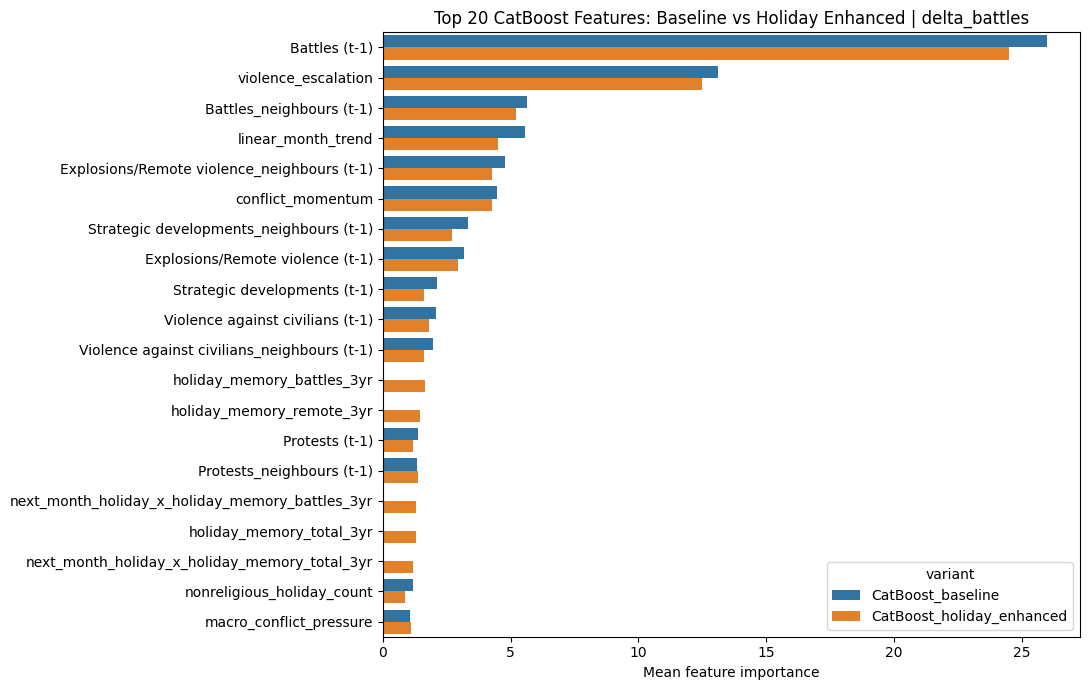

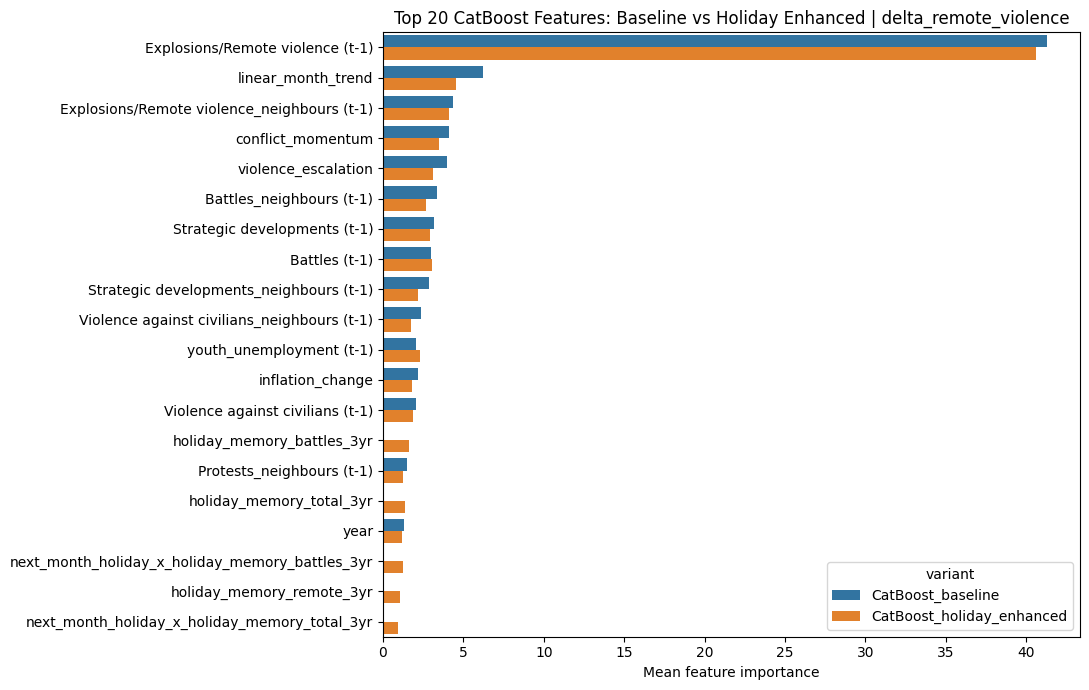

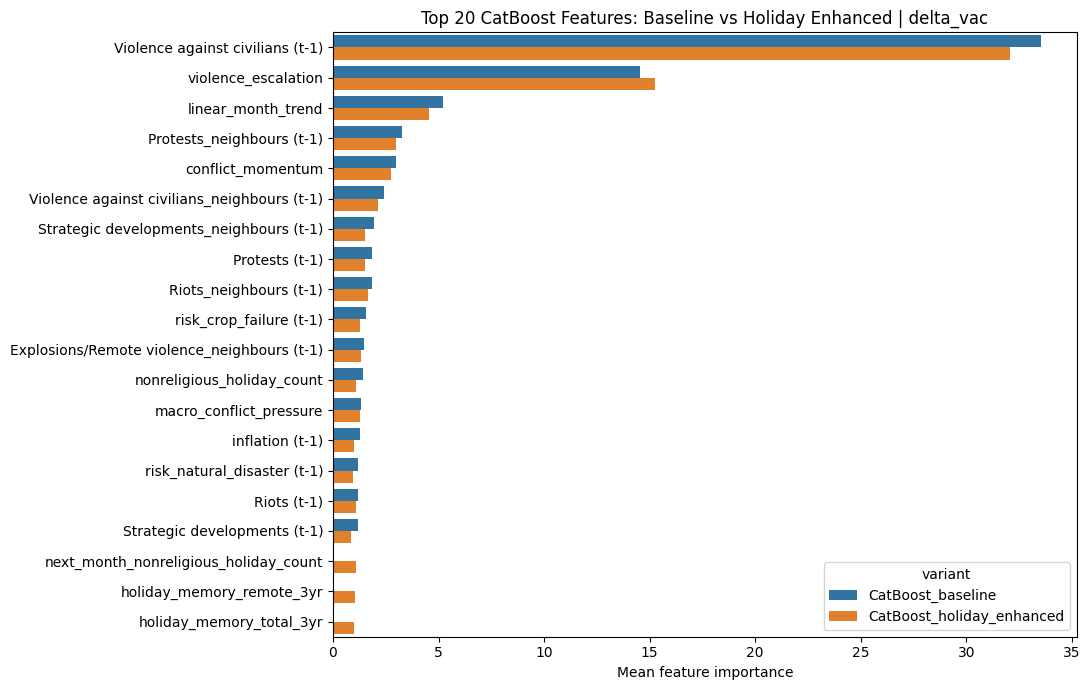

In [23]:
for target in DELTA_TARGETS:
    top_features = (
        catboost_fi_summary[catboost_fi_summary['target'] == target]
        .groupby('feature')['importance']
        .max()
        .sort_values(ascending=False)
        .head(TOP_N)
        .index
    )

    plot_df = catboost_fi_summary[
        (catboost_fi_summary['target'] == target)
        & (catboost_fi_summary['feature'].isin(top_features))
    ].copy()

    order = (
        plot_df.groupby('feature')['importance']
        .max()
        .sort_values(ascending=False)
        .index
    )

    plt.figure(figsize=(11, 7))
    sns.barplot(
        data=plot_df,
        y='feature',
        x='importance',
        hue='variant',
        order=order,
    )
    plt.title(f'Top {TOP_N} CatBoost Features: Baseline vs Holiday Enhanced | {target}')
    plt.xlabel('Mean feature importance')
    plt.ylabel('')
    plt.tight_layout()
    plt.show()

In [24]:
# Phase 1: Persistence baseline for change targets
# For delta targets, persistence means "no change", so predicted delta = 0.

persistence_results = []

for region in VALID_REGIONS:
    region_data = model_data.loc[region].sort_index()
    train_data, test_data = split_region_data(region_data)

    for target in DELTA_TARGETS:
        y_test = test_data[target].dropna()

        if len(y_test) == 0:
            continue

        y_pred = np.zeros(len(y_test))

        persistence_results.append({
            'region': region,
            'target': target,
            'model': 'Persistence_no_change',
            'mae': mean_absolute_error(y_test, y_pred),
            'rmse': rmse(y_test, y_pred),
            'mean_actual': y_test.mean(),
            'mean_pred': float(np.mean(y_pred)),
        })

persistence_results_df = pd.DataFrame(persistence_results)

persistence_summary = (
    persistence_results_df
    .groupby('target')[['mae', 'rmse', 'mean_actual', 'mean_pred']]
    .mean()
    .round(3)
)

persistence_summary

,mae,rmse,mean_actual,mean_pred
target,,,,
delta_battles,0.902,1.162,-0.147,0.0
delta_remote_violence,1.119,1.413,-0.088,0.0
delta_vac,0.771,0.984,-0.084,0.0


In [25]:
# Compare CatBoost against persistence

catboost_baseline_results_df = (
    catboost_compare_df[catboost_compare_df['variant'] == 'CatBoost_baseline']
    .copy()
)

catboost_baseline_results_df['model'] = 'CatBoost'

catboost_summary = (
    catboost_baseline_results_df
    .groupby('target')[['mae', 'rmse', 'mean_actual', 'mean_pred']]
    .mean()
)

persistence_summary_raw = (
    persistence_results_df
    .groupby('target')[['mae', 'rmse', 'mean_actual', 'mean_pred']]
    .mean()
)

persistence_compare = catboost_summary[['mae', 'rmse']].join(
    persistence_summary_raw[['mae', 'rmse']],
    rsuffix='_persistence'
)

persistence_compare['mae_improvement_pct_vs_persistence'] = (
    (persistence_compare['mae_persistence'] - persistence_compare['mae'])
    / persistence_compare['mae_persistence']
    * 100
)

persistence_compare['rmse_improvement_pct_vs_persistence'] = (
    (persistence_compare['rmse_persistence'] - persistence_compare['rmse'])
    / persistence_compare['rmse_persistence']
    * 100
)

persistence_compare.round(3)

,mae,rmse,mae_persistence,rmse_persistence,mae_improvement_pct_vs_persistence,rmse_improvement_pct_vs_persistence
target,,,,,,
delta_battles,1.607,2.030,0.902,1.162,-78.251,-74.690
delta_remote_violence,3.011,3.634,1.119,1.413,-169.070,-157.187
delta_vac,0.886,1.096,0.771,0.984,-14.882,-11.373


In [26]:
combined_persistence_score = pd.DataFrame({
    'catboost_mean_mae': [persistence_compare['mae'].mean()],
    'persistence_mean_mae': [persistence_compare['mae_persistence'].mean()],
    'catboost_mean_rmse': [persistence_compare['rmse'].mean()],
    'persistence_mean_rmse': [persistence_compare['rmse_persistence'].mean()],
})

combined_persistence_score['mean_mae_improvement_pct_vs_persistence'] = (
    (combined_persistence_score['persistence_mean_mae'] - combined_persistence_score['catboost_mean_mae'])
    / combined_persistence_score['persistence_mean_mae']
    * 100
)

combined_persistence_score['mean_rmse_improvement_pct_vs_persistence'] = (
    (combined_persistence_score['persistence_mean_rmse'] - combined_persistence_score['catboost_mean_rmse'])
    / combined_persistence_score['persistence_mean_rmse']
    * 100
)

combined_persistence_score.round(3)


,catboost_mean_mae,persistence_mean_mae,catboost_mean_rmse,persistence_mean_rmse,mean_mae_improvement_pct_vs_persistence,mean_rmse_improvement_pct_vs_persistence
0,1.835,0.931,2.253,1.186,-97.156,-89.936


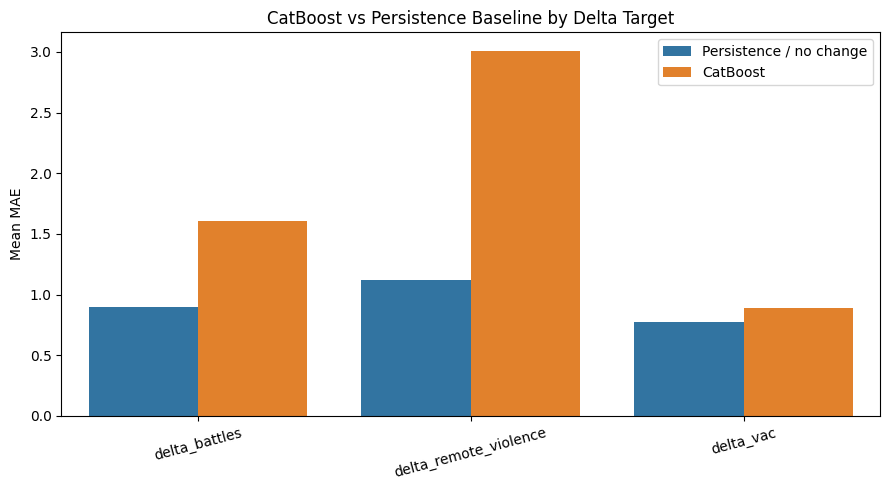

In [28]:
plot_df = (
    persistence_compare
    .reset_index()
    [['target', 'mae_persistence', 'mae']]
    .rename(columns={
        'mae_persistence': 'Persistence / no change',
        'mae': 'CatBoost'
    })
    .melt(
        id_vars='target',
        var_name='model',
        value_name='MAE'
    )
)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=plot_df,
    x='target',
    y='MAE',
    hue='model'
)

plt.title('CatBoost vs Persistence Baseline by Delta Target')
plt.xlabel('')
plt.ylabel('Mean MAE')
plt.xticks(rotation=15)
plt.legend(title='')
plt.tight_layout()
plt.show()

**finding** : The persistence baseline performs strongly because most delta targets are zero, so predicting “no change” is often correct. This does not necessarily mean CatBoost is unhelpful; rather, full-sample MAE rewards conservative zero predictions. The next evaluation should separate zero-delta months from nonzero-delta months to test whether CatBoost adds value on actual escalation/de-escalation cases.


In [12]:
# Split evaluation on zero-delta vs nonzero-delta rows
# Diagnostic only: small subset, not full final run.

RUN_REGIONS = VALID_REGIONS[:100]

split_eval_rows = []

for i, region in enumerate(RUN_REGIONS, start=1):
    if i % 25 == 0:
        print(f"Processed {i}/{len(RUN_REGIONS)} regions")

    region_data = model_data.loc[region].sort_index()
    train_data, test_data = split_region_data(region_data)

    weights_full = train_data['importance_weight'] if 'importance_weight' in train_data.columns else None

    for target in DELTA_TARGETS:
        train_pair = train_data[baseline_feature_cols + [target]].copy()
        test_pair = test_data[baseline_feature_cols + [target]].copy()

        train_pair = train_pair[train_pair[target].notna()]
        test_pair = test_pair[test_pair[target].notna()]

        if len(train_pair) == 0 or len(test_pair) == 0:
            continue

        y_train = train_pair[target]
        y_test = test_pair[target]

        if y_train.nunique() <= 1:
            continue

        weights = None
        if weights_full is not None:
            weights = weights_full.loc[train_pair.index]

        X_train_cb, X_test_cb, cat_cols_cb = prepare_catboost_inputs(
            train_pair,
            test_pair,
            baseline_feature_cols,
        )

        model = CatBoostRegressor(
            iterations=300,
            learning_rate=0.05,
            depth=4,
            random_seed=RANDOM_STATE,
            verbose=0,
        )

        fit_kwargs = {}
        if cat_cols_cb is not None:
            fit_kwargs['cat_features'] = cat_cols_cb
        if weights is not None:
            fit_kwargs['sample_weight'] = weights.values

        model.fit(X_train_cb, y_train, **fit_kwargs)
        catboost_pred = model.predict(X_test_cb)

        for month, actual, pred in zip(y_test.index, y_test.values, catboost_pred):
            split_eval_rows.append({
                'region': region,
                'month_year': month,
                'target': target,
                'actual_delta': actual,
                'model': 'CatBoost',
                'prediction': pred,
                'error_abs': abs(actual - pred),
                'delta_group': 'nonzero_delta' if actual != 0 else 'zero_delta',
            })

            split_eval_rows.append({
                'region': region,
                'month_year': month,
                'target': target,
                'actual_delta': actual,
                'model': 'Persistence_no_change',
                'prediction': 0.0,
                'error_abs': abs(actual - 0.0),
                'delta_group': 'nonzero_delta' if actual != 0 else 'zero_delta',
            })

split_eval_df = pd.DataFrame(split_eval_rows)

split_eval_summary = (
    split_eval_df
    .groupby(['target', 'delta_group', 'model'])['error_abs']
    .mean()
    .reset_index()
    .rename(columns={'error_abs': 'mae'})
)

split_eval_summary

Processed 25/100 regions
Processed 50/100 regions
Processed 75/100 regions
Processed 100/100 regions


,target,delta_group,model,mae
0,delta_battles,nonzero_delta,CatBoost,2.618395
1,delta_battles,nonzero_delta,Persistence_no_change,2.762887
2,delta_battles,zero_delta,CatBoost,0.225760
3,delta_battles,zero_delta,Persistence_no_change,0.000000
4,delta_remote_violence,nonzero_delta,CatBoost,1.425314
5,delta_remote_violence,nonzero_delta,Persistence_no_change,1.661017
6,delta_remote_violence,zero_delta,CatBoost,0.153296
7,delta_remote_violence,zero_delta,Persistence_no_change,0.000000
8,delta_vac,nonzero_delta,CatBoost,1.497597
9,delta_vac,nonzero_delta,Persistence_no_change,1.708661


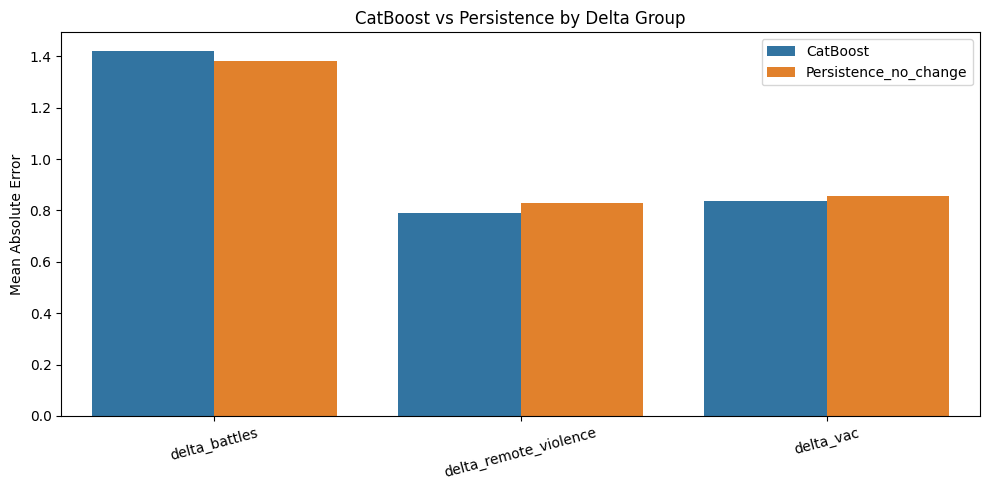

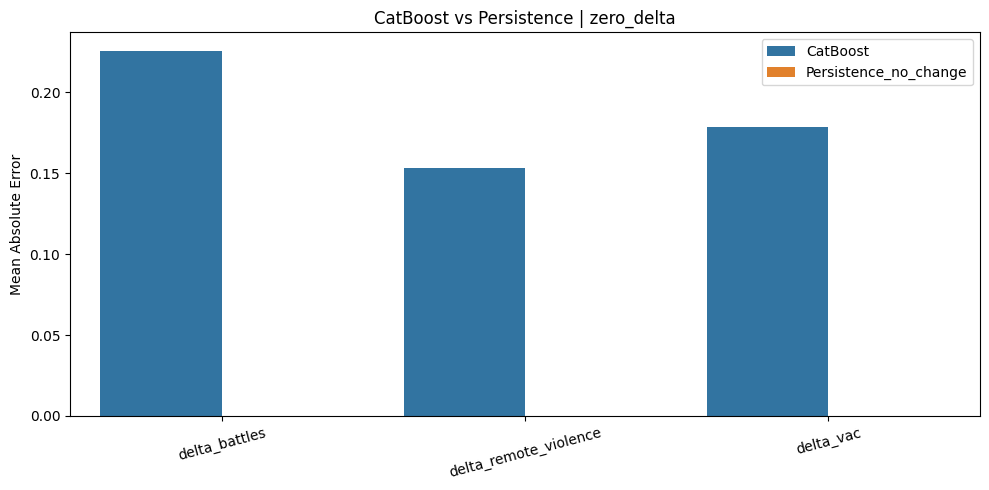

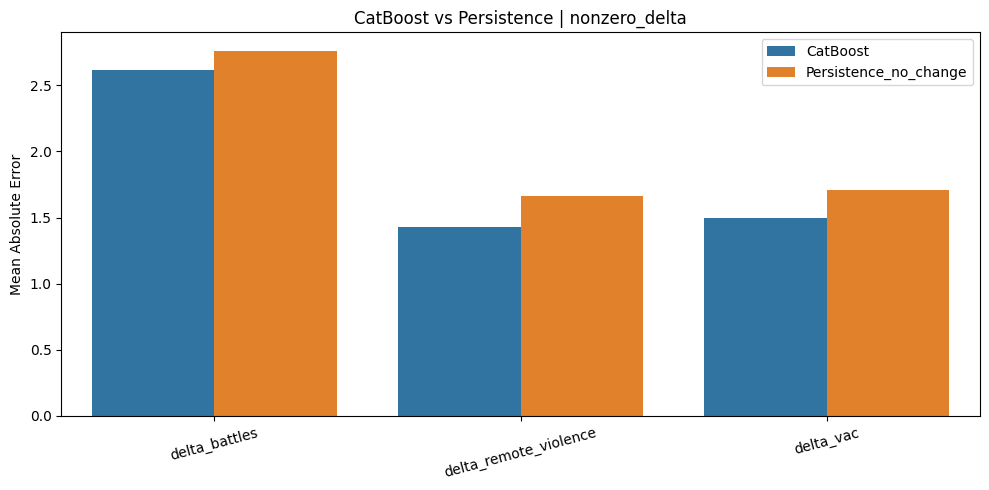

In [13]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=split_eval_summary,
    x='target',
    y='mae',
    hue='model',
    errorbar=None
)

plt.title('CatBoost vs Persistence by Delta Group')
plt.xlabel('')
plt.ylabel('Mean Absolute Error')
plt.xticks(rotation=15)
plt.legend(title='')

plt.tight_layout()
plt.show()

for group in ['zero_delta', 'nonzero_delta']:
    group_df = split_eval_summary[split_eval_summary['delta_group'] == group]

    plt.figure(figsize=(10, 5))
    sns.barplot(
        data=group_df,
        x='target',
        y='mae',
        hue='model',
        errorbar=None
    )
    plt.title(f'CatBoost vs Persistence | {group}')
    plt.xlabel('')
    plt.ylabel('Mean Absolute Error')
    plt.xticks(rotation=15)
    plt.legend(title='')
    plt.tight_layout()
    plt.show()

## Two-Stage Change Model

The split evaluation showed that persistence is strongest on zero-delta months, while CatBoost performs better on nonzero-delta months. This motivates a two-stage model:

1. Stage 1: classify whether the target delta is nonzero.
2. Stage 2: predict the signed delta magnitude only for nonzero-change cases.
3. Combined prediction: use the Stage 2 regression prediction only when Stage 1 predicts change; otherwise predict zero.


In [10]:
# Diagnostic run only: small subset.

from catboost import CatBoostClassifier


RUN_REGIONS = VALID_REGIONS[:100]
CHANGE_THRESHOLD = 0.50

two_stage_rows = []

for i, region in enumerate(RUN_REGIONS, start=1):
    if i % 25 == 0:
        print(f"Processed {i}/{len(RUN_REGIONS)} regions")

    region_data = model_data.loc[region].sort_index()
    train_data, test_data = split_region_data(region_data)

    weights_full = train_data['importance_weight'] if 'importance_weight' in train_data.columns else None

    for target in DELTA_TARGETS:
        train_pair = train_data[baseline_feature_cols + [target]].copy()
        test_pair = test_data[baseline_feature_cols + [target]].copy()

        train_pair = train_pair[train_pair[target].notna()]
        test_pair = test_pair[test_pair[target].notna()]

        if len(train_pair) == 0 or len(test_pair) == 0:
            continue

        y_train = train_pair[target]
        y_test = test_pair[target]

        # Need both classes for Stage 1.
        y_train_binary = (y_train != 0).astype(int)
        if y_train_binary.nunique() <= 1:
            continue

        weights = None
        if weights_full is not None:
            weights = weights_full.loc[train_pair.index]

        X_train, X_test, cat_cols = prepare_catboost_inputs(
            train_pair,
            test_pair,
            baseline_feature_cols,
        )

        fit_kwargs = {}
        if cat_cols is not None:
            fit_kwargs['cat_features'] = cat_cols
        if weights is not None:
            fit_kwargs['sample_weight'] = weights.values

        # Stage 1: will this month have nonzero change?
        clf = CatBoostClassifier(
            iterations=300,
            learning_rate=0.05,
            depth=4,
            random_seed=RANDOM_STATE,
            verbose=0,
        )

        clf.fit(X_train, y_train_binary, **fit_kwargs)
        change_prob = clf.predict_proba(X_test)[:, 1]
        change_flag = (change_prob >= CHANGE_THRESHOLD).astype(int)

        # Stage 2: signed magnitude, trained only on nonzero-change rows.
        nonzero_train_mask = y_train != 0

        if nonzero_train_mask.sum() < 5:
            # Not enough active rows to train the regressor safely.
            stage2_pred = np.zeros(len(y_test))
        else:
            reg = CatBoostRegressor(
                iterations=300,
                learning_rate=0.05,
                depth=4,
                random_seed=RANDOM_STATE,
                verbose=0,
            )

            X_train_nonzero = X_train.loc[nonzero_train_mask]
            y_train_nonzero = y_train.loc[nonzero_train_mask]

            reg_fit_kwargs = {}
            if cat_cols is not None:
                reg_fit_kwargs['cat_features'] = cat_cols
            if weights is not None:
                reg_fit_kwargs['sample_weight'] = weights.loc[nonzero_train_mask].values

            reg.fit(X_train_nonzero, y_train_nonzero, **reg_fit_kwargs)
            stage2_pred = reg.predict(X_test)

        two_stage_pred = change_flag * stage2_pred

        # One-stage CatBoost baseline on same small subset
        one_stage = CatBoostRegressor(
            iterations=300,
            learning_rate=0.05,
            depth=4,
            random_seed=RANDOM_STATE,
            verbose=0,
        )
        one_stage.fit(X_train, y_train, **fit_kwargs)
        one_stage_pred = one_stage.predict(X_test)

        for month, actual, pred_two, pred_one, pred_persist, prob in zip(
            y_test.index,
            y_test.values,
            two_stage_pred,
            one_stage_pred,
            np.zeros(len(y_test)),
            change_prob,
        ):
            delta_group = 'nonzero_delta' if actual != 0 else 'zero_delta'

            two_stage_rows.append({
                'region': region,
                'month_year': month,
                'target': target,
                'delta_group': delta_group,
                'model': 'TwoStage_CatBoost',
                'actual_delta': actual,
                'prediction': pred_two,
                'change_prob': prob,
                'abs_error': abs(actual - pred_two),
            })

            two_stage_rows.append({
                'region': region,
                'month_year': month,
                'target': target,
                'delta_group': delta_group,
                'model': 'OneStage_CatBoost',
                'actual_delta': actual,
                'prediction': pred_one,
                'change_prob': np.nan,
                'abs_error': abs(actual - pred_one),
            })

            two_stage_rows.append({
                'region': region,
                'month_year': month,
                'target': target,
                'delta_group': delta_group,
                'model': 'Persistence_no_change',
                'actual_delta': actual,
                'prediction': pred_persist,
                'change_prob': np.nan,
                'abs_error': abs(actual - pred_persist),
            })

two_stage_eval_df = pd.DataFrame(two_stage_rows)

two_stage_summary = (
    two_stage_eval_df
    .groupby(['target', 'delta_group', 'model'])['abs_error']
    .mean()
    .reset_index()
    .rename(columns={'abs_error': 'mae'})
)

two_stage_summary


Processed 25/100 regions
Processed 50/100 regions
Processed 75/100 regions
Processed 100/100 regions


,target,delta_group,model,mae
0,delta_battles,nonzero_delta,OneStage_CatBoost,2.618395
1,delta_battles,nonzero_delta,Persistence_no_change,2.762887
2,delta_battles,nonzero_delta,TwoStage_CatBoost,2.627507
3,delta_battles,zero_delta,OneStage_CatBoost,0.225760
4,delta_battles,zero_delta,Persistence_no_change,0.000000
5,delta_battles,zero_delta,TwoStage_CatBoost,0.187043
6,delta_remote_violence,nonzero_delta,OneStage_CatBoost,1.425314
7,delta_remote_violence,nonzero_delta,Persistence_no_change,1.661017
8,delta_remote_violence,nonzero_delta,TwoStage_CatBoost,1.395778
9,delta_remote_violence,zero_delta,OneStage_CatBoost,0.153296


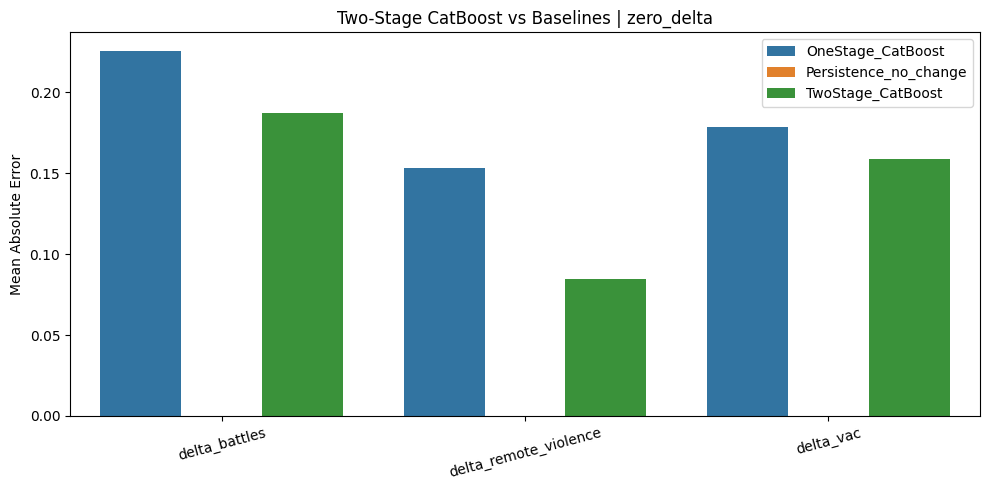

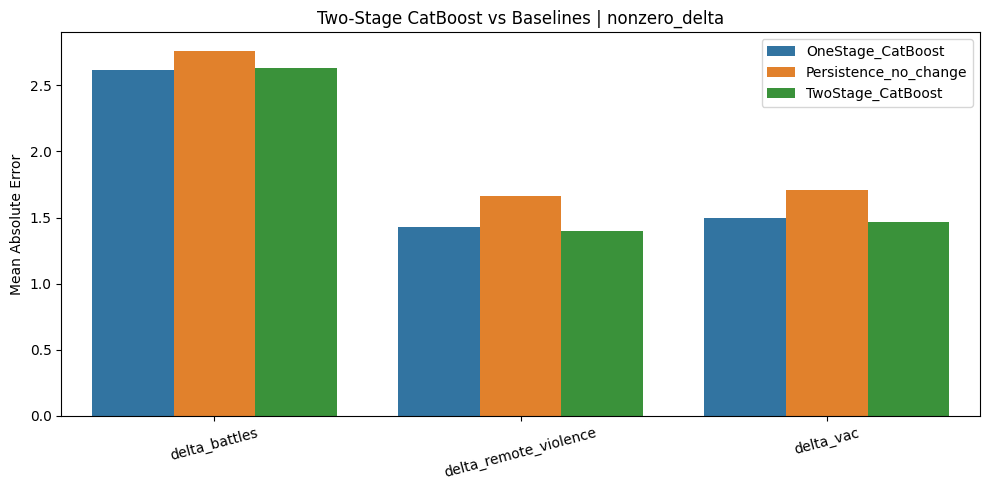

In [11]:
two_stage_compare = two_stage_summary.pivot_table(
    index=['target', 'delta_group'],
    columns='model',
    values='mae'
).reset_index()

two_stage_compare['two_stage_improvement_pct_vs_persistence'] = (
    (two_stage_compare['Persistence_no_change'] - two_stage_compare['TwoStage_CatBoost'])
    / two_stage_compare['Persistence_no_change']
    * 100
).round(2)

two_stage_compare['two_stage_improvement_pct_vs_one_stage'] = (
    (two_stage_compare['OneStage_CatBoost'] - two_stage_compare['TwoStage_CatBoost'])
    / two_stage_compare['OneStage_CatBoost']
    * 100
).round(2)

two_stage_compare.round(3)

plot_df = two_stage_summary.copy()

for group in ['zero_delta', 'nonzero_delta']:
    group_df = plot_df[plot_df['delta_group'] == group]

    plt.figure(figsize=(10, 5))
    sns.barplot(
        data=group_df,
        x='target',
        y='mae',
        hue='model',
        errorbar=None,
    )
    plt.title(f'Two-Stage CatBoost vs Baselines | {group}')
    plt.xlabel('')
    plt.ylabel('Mean Absolute Error')
    plt.xticks(rotation=15)
    plt.legend(title='')
    plt.tight_layout()
    plt.show()

**findins**: The two-stage CatBoost setup improves the behavior of the change-target model. It reduces error on zero-delta months by learning when to predict no change, while remaining competitive on nonzero-delta months. This supports treating signed conflict change as a two-part problem: first detecting whether change occurs, then estimating the signed magnitude.


In [12]:
# Top feature importance for the two-stage CatBoost model
# Small diagnostic only

RUN_REGIONS = VALID_REGIONS[:100]
RUN_TARGETS = DELTA_TARGETS

two_stage_fi_records = []

for region in RUN_REGIONS:
    region_data = model_data.loc[region].sort_index()
    train_data, test_data = split_region_data(region_data)

    for target in RUN_TARGETS:
        train_pair = train_data[baseline_feature_cols + [target]].copy()
        test_pair = test_data[baseline_feature_cols + [target]].copy()

        train_pair = train_pair[train_pair[target].notna()]
        test_pair = test_pair[test_pair[target].notna()]

        if len(train_pair) == 0 or len(test_pair) == 0:
            continue

        y_train = train_pair[target]
        y_test = test_pair[target]

        if y_train.nunique() <= 1:
            continue

        X_train_cb, X_test_cb, cat_cols_cb = prepare_catboost_inputs(
            train_pair,
            test_pair,
            baseline_feature_cols
        )

        y_train_nonzero_flag = (y_train != 0).astype(int)

        if y_train_nonzero_flag.nunique() <= 1:
            continue

        clf = CatBoostClassifier(
            iterations=200,
            depth=6,
            learning_rate=0.05,
            loss_function='Logloss',
            verbose=False,
            random_seed=42,
            allow_writing_files=False
        )

        clf_kwargs = {}
        if cat_cols_cb is not None:
            clf_kwargs['cat_features'] = cat_cols_cb

        clf.fit(X_train_cb, y_train_nonzero_flag, **clf_kwargs)

        stage1_fi = pd.DataFrame({
            'stage': 'Stage 1 - nonzero classifier',
            'target': target,
            'region': region,
            'feature': baseline_feature_cols,
            'importance': clf.feature_importances_
        })

        two_stage_fi_records.append(stage1_fi)

        nonzero_train_mask = y_train != 0

        if nonzero_train_mask.sum() < 5:
            continue

        reg = CatBoostRegressor(
            iterations=300,
            depth=6,
            learning_rate=0.05,
            loss_function='RMSE',
            verbose=False,
            random_seed=42,
            allow_writing_files=False
        )

        reg_kwargs = {}
        if cat_cols_cb is not None:
            reg_kwargs['cat_features'] = cat_cols_cb

        reg.fit(
            X_train_cb.loc[nonzero_train_mask],
            y_train.loc[nonzero_train_mask],
            **reg_kwargs
        )

        stage2_fi = pd.DataFrame({
            'stage': 'Stage 2 - magnitude regressor',
            'target': target,
            'region': region,
            'feature': baseline_feature_cols,
            'importance': reg.feature_importances_
        })

        two_stage_fi_records.append(stage2_fi)

two_stage_fi_df = pd.concat(two_stage_fi_records, ignore_index=True)

two_stage_top25 = (
    two_stage_fi_df
    .groupby(['stage', 'target', 'feature'], as_index=False)['importance']
    .mean()
    .sort_values(['stage', 'target', 'importance'], ascending=[True, True, False])
    .groupby(['stage', 'target'])
    .head(25)
)

two_stage_top25

,stage,target,feature,importance
1,Stage 1 - nonzero classifier,delta_battles,Battles (t-1),9.657764
74,Stage 1 - nonzero classifier,delta_battles,violence_escalation,7.011477
29,Stage 1 - nonzero classifier,delta_battles,linear_month_trend,5.420234
17,Stage 1 - nonzero classifier,delta_battles,conflict_momentum,5.066636
2,Stage 1 - nonzero classifier,delta_battles,Battles_neighbours (t-1),3.874259
...,...,...,...,...
423,Stage 2 - magnitude regressor,delta_vac,inflation (t-1),0.826072
438,Stage 2 - magnitude regressor,delta_vac,minority_tension_minority2,0.801871
477,Stage 2 - magnitude regressor,delta_vac,weighted_holidays_minority2,0.775608
475,Stage 2 - magnitude regressor,delta_vac,weighted_holidays_majority,0.740956


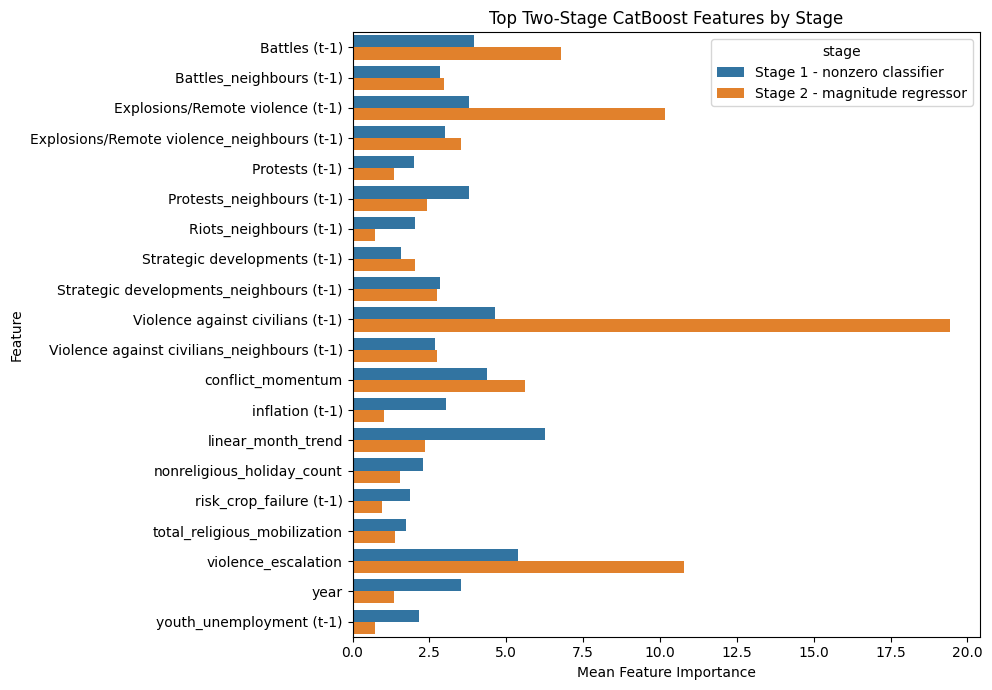

In [16]:
## Plot top 20 features averaged across all three targets, by stage.

plot_fi = (
    two_stage_fi_df
    .groupby(['stage', 'feature'], as_index=False)['importance']
    .mean()
)

top_features = (
    plot_fi
    .groupby('feature')['importance']
    .mean()
    .sort_values(ascending=False)
    .head(20)
    .index
)

plot_fi_top = plot_fi[plot_fi['feature'].isin(top_features)]

plt.figure(figsize=(10, 7))
sns.barplot(
    data=plot_fi_top,
    y='feature',
    x='importance',
    hue='stage'
)

plt.title('Top Two-Stage CatBoost Features by Stage')
plt.xlabel('Mean Feature Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Target Encoding 


In [32]:
SMOOTHING_K = 5
RELIGION_COLS_TE = ['majority_religion', 'minority1_religion', 'minority2_religion']

train_flat = pd.concat([
    model_data.loc[region].sort_index().iloc[:-6].assign(matched_admin1_id=region)
    for region in VALID_REGIONS[:100]
])

religion_te = {}
for suffix, raw_col in [
    ('battles', 'Battles'),
    ('remote_violence', 'Explosions/Remote violence'),
    ('vac', 'Violence against civilians'),
]:
    global_mean = train_flat[raw_col].mean()
    for rel_col in RELIGION_COLS_TE:
        feat_name = f'te_{rel_col}_{suffix}'
        stats = train_flat.groupby(rel_col)[raw_col].agg(['mean', 'count'])
        stats['smoothed'] = (
            (stats['count'] * stats['mean'] + SMOOTHING_K * global_mean)
            / (stats['count'] + SMOOTHING_K)
        )
        religion_te[feat_name] = stats['smoothed'].to_dict()

RELIGION_TE_COLS = list(religion_te.keys())
print(f"Built {len(RELIGION_TE_COLS)} religion TE features")

Built 9 religion TE features


In [33]:
def apply_religion_te(df, religion_te):
    df = df.copy()
    for feat_name, enc_dict in religion_te.items():
        rel_col = next(r for r in RELIGION_COLS_TE if r in feat_name)
        fallback = float(np.mean(list(enc_dict.values())))
        df[feat_name] = df[rel_col].astype(str).map(
            lambda x, ed=enc_dict: ed.get(x, fallback)
        )
    return df

te_cols = list(dict.fromkeys(baseline_feature_cols + RELIGION_TE_COLS))

te_rows = []

for i, region in enumerate(VALID_REGIONS[:100], start=1):
    if i % 25 == 0:
        print(f"{i}/100 regions")

    region_data = model_data.loc[region].sort_index()
    train_data, test_data = split_region_data(region_data)
    train_te = apply_religion_te(train_data, religion_te)
    test_te  = apply_religion_te(test_data,  religion_te)

    weights_full = train_data['importance_weight'] if 'importance_weight' in train_data.columns else None

    for target in DELTA_TARGETS:
        train_pair = train_te[te_cols + [target]].dropna(subset=[target])
        test_pair  = test_te[te_cols  + [target]].dropna(subset=[target])

        if len(train_pair) == 0 or len(test_pair) == 0:
            continue

        y_train = train_pair[target]
        y_test  = test_pair[target]

        y_bin = (y_train != 0).astype(int)
        if y_bin.nunique() <= 1:
            continue

        weights = weights_full.loc[train_pair.index] if weights_full is not None else None

        X_train, X_test, cat_cols = prepare_catboost_inputs(train_pair, test_pair, te_cols)

        fit_kw = {}
        if cat_cols: fit_kw['cat_features'] = cat_cols
        if weights is not None: fit_kw['sample_weight'] = weights.values

        clf = CatBoostClassifier(iterations=300, learning_rate=0.05, depth=4, random_seed=RANDOM_STATE, verbose=0)
        clf.fit(X_train, y_bin, **fit_kw)
        change_flag = (clf.predict_proba(X_test)[:, 1] >= 0.5).astype(int)

        nonzero_mask = y_train != 0
        if nonzero_mask.sum() < 5:
            stage2_pred = np.zeros(len(y_test))
        else:
            reg = CatBoostRegressor(iterations=300, learning_rate=0.05, depth=4, random_seed=RANDOM_STATE, verbose=0)
            reg_kw = {k: v for k, v in fit_kw.items() if k != 'sample_weight'}
            if weights is not None: reg_kw['sample_weight'] = weights.loc[nonzero_mask].values
            reg.fit(X_train.loc[nonzero_mask], y_train.loc[nonzero_mask], **reg_kw)
            stage2_pred = reg.predict(X_test)

        for actual, pred in zip(y_test.values, change_flag * stage2_pred):
            te_rows.append({
                'target': target,
                'delta_group': 'nonzero_delta' if actual != 0 else 'zero_delta',
                'actual': actual,
                'pred': pred,
                'abs_error': abs(actual - pred),
            })

te_results = pd.DataFrame(te_rows)
te_summary = (
    te_results
    .groupby(['target', 'delta_group'])['abs_error']
    .mean()
    .reset_index()
    .rename(columns={'abs_error': 'mae'})
)
te_summary

25/100 regions
50/100 regions
75/100 regions
100/100 regions


,target,delta_group,mae
0,delta_battles,nonzero_delta,2.627507
1,delta_battles,zero_delta,0.187043
2,delta_remote_violence,nonzero_delta,1.395778
3,delta_remote_violence,zero_delta,0.084592
4,delta_vac,nonzero_delta,1.470370
5,delta_vac,zero_delta,0.158890


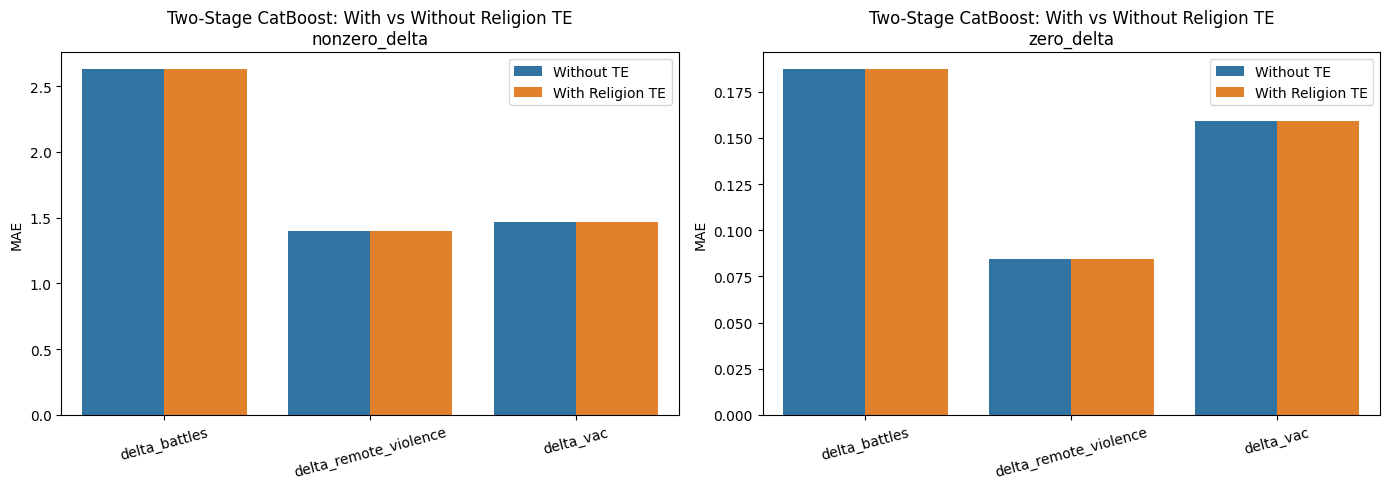

In [34]:
comparison_df = two_stage_summary[two_stage_summary['model'] == 'TwoStage_CatBoost'][['target', 'delta_group', 'mae']].copy()
comparison_df['model'] = 'Without TE'

te_plot = te_summary.copy()
te_plot['model'] = 'With Religion TE'

plot_df = pd.concat([comparison_df, te_plot], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, group in zip(axes, ['nonzero_delta', 'zero_delta']):
    data = plot_df[plot_df['delta_group'] == group]
    sns.barplot(data=data, x='target', y='mae', hue='model', ax=ax)
    ax.set_title(f'Two-Stage CatBoost: With vs Without Religion TE\n{group}')
    ax.set_xlabel('')
    ax.set_ylabel('MAE')
    ax.tick_params(axis='x', rotation=15)
    ax.legend(title='')

plt.tight_layout()
plt.show()

**finding**: as we can see in plot, it did not make any chage. based on the feature engineering in earlier steps we did with holidays and religion and combining them and also catboost categorical features itself it could not change anything. I guess maybe with Lgbm(poisson or tweedie) might actually have more effect.

## Additional lags

In [13]:
# Compute t-6 and t-12 lags for conflict and risk columns
# Must be computed per region to avoid cross-region leakage

CONFLICT_COLS_TO_LAG = [
    'Battles',
    'Explosions/Remote violence',
    'Protests',
    'Riots',
    'Strategic developments',
    'Violence against civilians',
    'Excessive force against protesters',
    'Agreement',
]

RISK_COLS_TO_LAG = [
    'risk_contested_election',
    'risk_crop_failure',
    'risk_economic_concern',
    'risk_ethnic_tension',
    'risk_military_coup',
    'risk_natural_disaster',
    'risk_political_assassination',
]

COLS_TO_LAG = CONFLICT_COLS_TO_LAG + RISK_COLS_TO_LAG
LAG_PERIODS = [6, 12]

for lag in LAG_PERIODS:
    for col in COLS_TO_LAG:
        if col not in model_data.columns:
            continue
        new_col = f'{col} (t-{lag})'
        model_data[new_col] = (
            model_data.groupby(level='matched_admin1_id')[col]
            .shift(lag)
        )

# Verify
new_lag_cols = [f'{c} (t-{l})' for l in LAG_PERIODS for c in COLS_TO_LAG if c in model_data.columns]
print(f"New lag columns added: {len(new_lag_cols)}")
print(new_lag_cols[:5])

New lag columns added: 20
['Battles (t-6)', 'Explosions/Remote violence (t-6)', 'Violence against civilians (t-6)', 'risk_contested_election (t-6)', 'risk_crop_failure (t-6)']


In [14]:
# Extended feature set with t-6 and t-12 lags
conflict_lag_features_extended = (
    conflict_lag_features  # existing t-1
    + [f'{c} (t-6)'  for c in CONFLICT_COLS_TO_LAG if f'{c} (t-6)'  in model_data.columns]
    + [f'{c} (t-12)' for c in CONFLICT_COLS_TO_LAG if f'{c} (t-12)' in model_data.columns]
)

risk_features_extended = (
    risk_features  # existing current + t-1
    + [f'{c} (t-6)'  for c in RISK_COLS_TO_LAG if f'{c} (t-6)'  in model_data.columns]
    + [f'{c} (t-12)' for c in RISK_COLS_TO_LAG if f'{c} (t-12)' in model_data.columns]
)

extended_feature_cols = list(dict.fromkeys(
    conflict_lag_features_extended
    + neighbor_features        # t-1 only
    + time_features
    + worldbank_lag_features   # t-1 only
    + religion_features
    + holiday_current_features
    + holiday_interaction_current
    + wbd_engineered_features
    + risk_features_extended
))

print(f"Baseline features:  {len(baseline_feature_cols)}")
print(f"Extended features:  {len(extended_feature_cols)}")
print(f"New features added: {len(extended_feature_cols) - len(baseline_feature_cols)}")

Baseline features:  80
Extended features:  100
New features added: 20


In [15]:
# Two-stage CatBoost with extended lag features (t-6, t-12)

extended_lag_rows = []

for i, region in enumerate(VALID_REGIONS[:100], start=1):
    if i % 25 == 0:
        print(f"{i}/100 regions")

    region_data = model_data.loc[region].sort_index()
    train_data, test_data = split_region_data(region_data)

    weights_full = train_data['importance_weight'] if 'importance_weight' in train_data.columns else None

    for target in DELTA_TARGETS:
        train_pair = train_data[extended_feature_cols + [target]].dropna(subset=[target])
        test_pair  = test_data[extended_feature_cols  + [target]].dropna(subset=[target])

        if len(train_pair) == 0 or len(test_pair) == 0:
            continue

        y_train = train_pair[target]
        y_test  = test_pair[target]

        y_bin = (y_train != 0).astype(int)
        if y_bin.nunique() <= 1:
            continue

        weights = weights_full.loc[train_pair.index] if weights_full is not None else None

        X_train, X_test, cat_cols = prepare_catboost_inputs(
            train_pair, test_pair, extended_feature_cols
        )

        fit_kw = {}
        if cat_cols: fit_kw['cat_features'] = cat_cols
        if weights is not None: fit_kw['sample_weight'] = weights.values

        # Stage 1
        clf = CatBoostClassifier(
            iterations=300, learning_rate=0.05, depth=4,
            random_seed=RANDOM_STATE, verbose=0,
        )
        clf.fit(X_train, y_bin, **fit_kw)
        change_flag = (clf.predict_proba(X_test)[:, 1] >= 0.5).astype(int)

        # Stage 2
        nonzero_mask = y_train != 0
        if nonzero_mask.sum() < 5:
            stage2_pred = np.zeros(len(y_test))
        else:
            reg = CatBoostRegressor(
                iterations=300, learning_rate=0.05, depth=4,
                random_seed=RANDOM_STATE, verbose=0,
            )
            reg_kw = {k: v for k, v in fit_kw.items() if k != 'sample_weight'}
            if weights is not None: reg_kw['sample_weight'] = weights.loc[nonzero_mask].values
            reg.fit(X_train.loc[nonzero_mask], y_train.loc[nonzero_mask], **reg_kw)
            stage2_pred = reg.predict(X_test)

        final_pred = change_flag * stage2_pred

        for actual, pred in zip(y_test.values, final_pred):
            extended_lag_rows.append({
                'target': target,
                'delta_group': 'nonzero_delta' if actual != 0 else 'zero_delta',
                'actual': actual,
                'pred': pred,
                'abs_error': abs(actual - pred),
            })

extended_lag_df = pd.DataFrame(extended_lag_rows)

extended_lag_summary = (
    extended_lag_df
    .groupby(['target', 'delta_group'])['abs_error']
    .mean()
    .reset_index()
    .rename(columns={'abs_error': 'mae'})
)

extended_lag_summary

25/100 regions
50/100 regions
75/100 regions
100/100 regions


,target,delta_group,mae
0,delta_battles,nonzero_delta,2.733173
1,delta_battles,zero_delta,0.324678
2,delta_remote_violence,nonzero_delta,1.359403
3,delta_remote_violence,zero_delta,0.077650
4,delta_vac,nonzero_delta,1.376764
5,delta_vac,zero_delta,0.155935


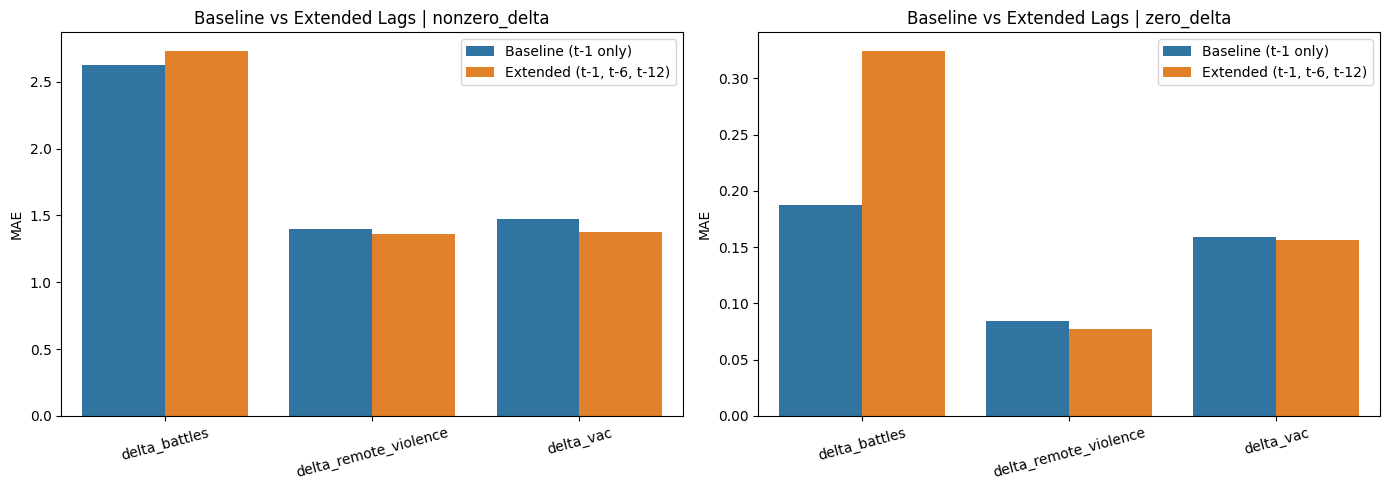

In [16]:
baseline_plot = two_stage_summary[
    two_stage_summary['model'] == 'TwoStage_CatBoost'
][['target', 'delta_group', 'mae']].copy()
baseline_plot['model'] = 'Baseline (t-1 only)'

extended_plot = extended_lag_summary.copy()
extended_plot['model'] = 'Extended (t-1, t-6, t-12)'

plot_df = pd.concat([baseline_plot, extended_plot], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, group in zip(axes, ['nonzero_delta', 'zero_delta']):
    data = plot_df[plot_df['delta_group'] == group]
    sns.barplot(data=data, x='target', y='mae', hue='model', ax=ax)
    ax.set_title(f'Baseline vs Extended Lags | {group}')
    ax.set_xlabel('')
    ax.set_ylabel('MAE')
    ax.tick_params(axis='x', rotation=15)
    ax.legend(title='')

plt.tight_layout()
plt.show()

**finding**: 


Nonzero delta (what matters):

delta_battles: ***worse*** with extended lags
delta_remote_violence: better 
delta_vac: better 

Zero delta:

delta_battles: ***much worse***
delta_remote_violence:slightly better
delta_vac: marginally better

extended lags help remote_violence and VAC but hurt battles, especially on zero-delta months. The battles model is getting confused by the additional lags, likely because battles is the most volatile and t-6/t-12 are noisy signals for it.
This suggests a per-target lag strategy: for battles keep t-1 only and for remote_violence and VAC use extended lags (t-1, t-6, t-12)

In [17]:
# Per-target lag 

per_target_feature_cols = {
    'delta_battles':         baseline_feature_cols,
    'delta_remote_violence': extended_feature_cols,
    'delta_vac':             extended_feature_cols,
}

per_target_rows = []

for i, region in enumerate(VALID_REGIONS[:100], start=1):
    if i % 25 == 0:
        print(f"{i}/100 regions")

    region_data = model_data.loc[region].sort_index()
    train_data, test_data = split_region_data(region_data)

    weights_full = train_data['importance_weight'] if 'importance_weight' in train_data.columns else None

    for target in DELTA_TARGETS:
        feat_cols = per_target_feature_cols[target]

        train_pair = train_data[feat_cols + [target]].dropna(subset=[target])
        test_pair  = test_data[feat_cols  + [target]].dropna(subset=[target])

        if len(train_pair) == 0 or len(test_pair) == 0:
            continue

        y_train = train_pair[target]
        y_test  = test_pair[target]

        y_bin = (y_train != 0).astype(int)
        if y_bin.nunique() <= 1:
            continue

        weights = weights_full.loc[train_pair.index] if weights_full is not None else None

        X_train, X_test, cat_cols = prepare_catboost_inputs(
            train_pair, test_pair, feat_cols
        )

        fit_kw = {}
        if cat_cols: fit_kw['cat_features'] = cat_cols
        if weights is not None: fit_kw['sample_weight'] = weights.values

        # Stage 1
        clf = CatBoostClassifier(
            iterations=300, learning_rate=0.05, depth=4,
            random_seed=RANDOM_STATE, verbose=0,
        )
        clf.fit(X_train, y_bin, **fit_kw)
        change_flag = (clf.predict_proba(X_test)[:, 1] >= 0.5).astype(int)

        # Stage 2
        nonzero_mask = y_train != 0
        if nonzero_mask.sum() < 5:
            stage2_pred = np.zeros(len(y_test))
        else:
            reg = CatBoostRegressor(
                iterations=300, learning_rate=0.05, depth=4,
                random_seed=RANDOM_STATE, verbose=0,
            )
            reg_kw = {k: v for k, v in fit_kw.items() if k != 'sample_weight'}
            if weights is not None: reg_kw['sample_weight'] = weights.loc[nonzero_mask].values
            reg.fit(X_train.loc[nonzero_mask], y_train.loc[nonzero_mask], **reg_kw)
            stage2_pred = reg.predict(X_test)

        for actual, pred in zip(y_test.values, change_flag * stage2_pred):
            per_target_rows.append({
                'target': target,
                'delta_group': 'nonzero_delta' if actual != 0 else 'zero_delta',
                'actual': actual,
                'pred': pred,
                'abs_error': abs(actual - pred),
            })

per_target_df = pd.DataFrame(per_target_rows)

per_target_summary = (
    per_target_df
    .groupby(['target', 'delta_group'])['abs_error']
    .mean()
    .reset_index()
    .rename(columns={'abs_error': 'mae'})
)

per_target_summary

25/100 regions
50/100 regions
75/100 regions
100/100 regions


,target,delta_group,mae
0,delta_battles,nonzero_delta,2.627507
1,delta_battles,zero_delta,0.187043
2,delta_remote_violence,nonzero_delta,1.359403
3,delta_remote_violence,zero_delta,0.077650
4,delta_vac,nonzero_delta,1.376764
5,delta_vac,zero_delta,0.155935


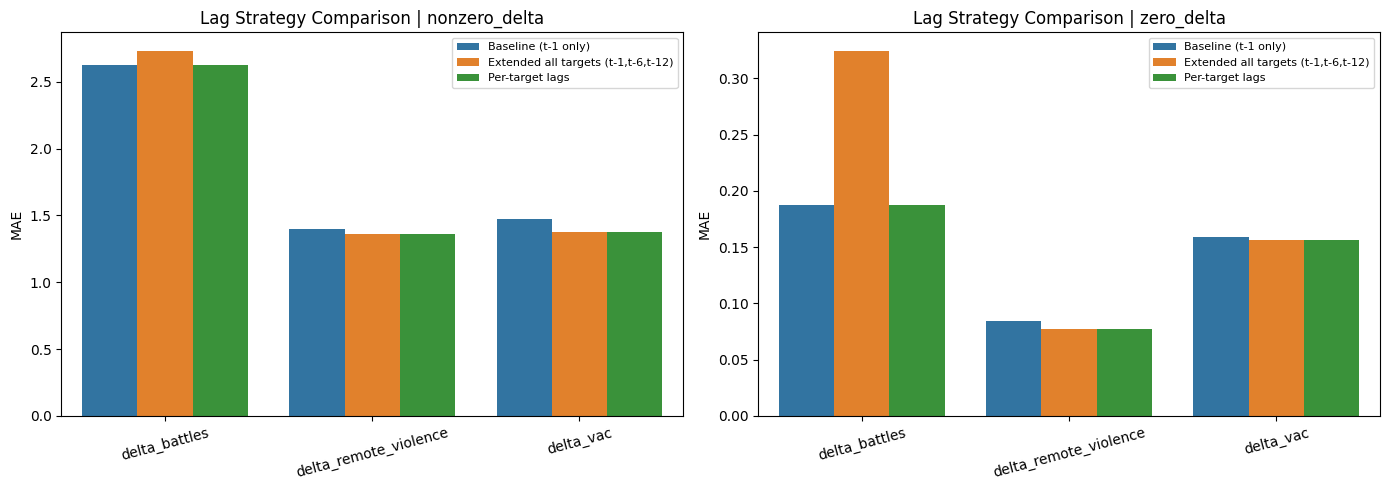

In [18]:
baseline_plot = two_stage_summary[
    two_stage_summary['model'] == 'TwoStage_CatBoost'
][['target', 'delta_group', 'mae']].copy()
baseline_plot['model'] = 'Baseline (t-1 only)'

extended_plot = extended_lag_summary.copy()
extended_plot['model'] = 'Extended all targets (t-1,t-6,t-12)'

per_target_plot = per_target_summary.copy()
per_target_plot['model'] = 'Per-target lags'

plot_df = pd.concat([baseline_plot, extended_plot, per_target_plot], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, group in zip(axes, ['nonzero_delta', 'zero_delta']):
    data = plot_df[plot_df['delta_group'] == group]
    sns.barplot(data=data, x='target', y='mae', hue='model', ax=ax)
    ax.set_title(f'Lag Strategy Comparison | {group}')
    ax.set_xlabel('')
    ax.set_ylabel('MAE')
    ax.tick_params(axis='x', rotation=15)
    ax.legend(title='', fontsize=8)

plt.tight_layout()
plt.show()

In [19]:
per_target_fi_records = []
per_target_fi_rows = []

for i, region in enumerate(VALID_REGIONS[:100], start=1):
    if i % 25 == 0:
        print(f"{i}/100 regions")

    region_data = model_data.loc[region].sort_index()
    train_data, test_data = split_region_data(region_data)
    weights_full = train_data['importance_weight'] if 'importance_weight' in train_data.columns else None

    for target in DELTA_TARGETS:
        feat_cols = per_target_feature_cols[target]

        train_pair = train_data[feat_cols + [target]].dropna(subset=[target])
        test_pair  = test_data[feat_cols  + [target]].dropna(subset=[target])

        if len(train_pair) == 0 or len(test_pair) == 0:
            continue

        y_train = train_pair[target]
        y_test  = test_pair[target]

        y_bin = (y_train != 0).astype(int)
        if y_bin.nunique() <= 1:
            continue

        weights = weights_full.loc[train_pair.index] if weights_full is not None else None
        X_train, X_test, cat_cols = prepare_catboost_inputs(train_pair, test_pair, feat_cols)

        fit_kw = {}
        if cat_cols: fit_kw['cat_features'] = cat_cols
        if weights is not None: fit_kw['sample_weight'] = weights.values

        clf = CatBoostClassifier(iterations=300, learning_rate=0.05, depth=4, random_seed=RANDOM_STATE, verbose=0)
        clf.fit(X_train, y_bin, **fit_kw)
        change_flag = (clf.predict_proba(X_test)[:, 1] >= 0.5).astype(int)

        per_target_fi_records.append(pd.DataFrame({
            'stage': 'Stage 1 - nonzero classifier',
            'feature': feat_cols,
            'importance': clf.feature_importances_,
        }))

        nonzero_mask = y_train != 0
        if nonzero_mask.sum() >= 5:
            reg = CatBoostRegressor(iterations=300, learning_rate=0.05, depth=4, random_seed=RANDOM_STATE, verbose=0)
            reg_kw = {k: v for k, v in fit_kw.items() if k != 'sample_weight'}
            if weights is not None: reg_kw['sample_weight'] = weights.loc[nonzero_mask].values
            reg.fit(X_train.loc[nonzero_mask], y_train.loc[nonzero_mask], **reg_kw)

            per_target_fi_records.append(pd.DataFrame({
                'stage': 'Stage 2 - magnitude regressor',
                'feature': feat_cols,
                'importance': reg.feature_importances_,
            }))

per_target_fi_df = pd.concat(per_target_fi_records, ignore_index=True)
print("Done.")

25/100 regions
50/100 regions
75/100 regions
100/100 regions
Done.


In [20]:
# t-6 only (replace t-1 with t-6 for conflict and risk, keep rest same)
conflict_lag_t6_only = (
    [f'{c} (t-6)' for c in CONFLICT_COLS_TO_LAG if f'{c} (t-6)' in model_data.columns]
)
risk_t6_only = (
    [c for c in risk_features if '(t-1)' not in c]  # current risk only
    + [f'{c} (t-6)' for c in RISK_COLS_TO_LAG if f'{c} (t-6)' in model_data.columns]
)
extended_t6_only_cols = list(dict.fromkeys(
    conflict_lag_t6_only
    + neighbor_features
    + time_features
    + worldbank_lag_features
    + religion_features
    + holiday_current_features
    + holiday_interaction_current
    + wbd_engineered_features
    + risk_t6_only
))

# t-1 + t-6 (no t-12)
conflict_lag_t1_t6 = (
    conflict_lag_features
    + [f'{c} (t-6)' for c in CONFLICT_COLS_TO_LAG if f'{c} (t-6)' in model_data.columns]
)
risk_t1_t6 = (
    risk_features
    + [f'{c} (t-6)' for c in RISK_COLS_TO_LAG if f'{c} (t-6)' in model_data.columns]
)
extended_t1_t6_cols = list(dict.fromkeys(
    conflict_lag_t1_t6
    + neighbor_features
    + time_features
    + worldbank_lag_features
    + religion_features
    + holiday_current_features
    + holiday_interaction_current
    + wbd_engineered_features
    + risk_t1_t6
))

per_target_t6_only = {
    'delta_battles':         baseline_feature_cols,
    'delta_remote_violence': extended_t6_only_cols,
    'delta_vac':             extended_t6_only_cols,
}

per_target_t1_t6 = {
    'delta_battles':         baseline_feature_cols,
    'delta_remote_violence': extended_t1_t6_cols,
    'delta_vac':             extended_t1_t6_cols,
}

print(f"t-6 only cols (remote/vac):  {len(extended_t6_only_cols)}")
print(f"t-1+t-6 cols (remote/vac):   {len(extended_t1_t6_cols)}")
print(f"t-1+t-6+t-12 cols (remote/vac): {len(extended_feature_cols)}")

t-6 only cols (remote/vac):  75
t-1+t-6 cols (remote/vac):   90
t-1+t-6+t-12 cols (remote/vac): 100


In [21]:
def run_two_stage_with_fi(per_target_feat_cols, regions, label):
    rows = []
    fi_records = []

    for i, region in enumerate(regions, start=1):
        if i % 25 == 0:
            print(f"{label}: {i}/{len(regions)} regions")

        region_data = model_data.loc[region].sort_index()
        train_data, test_data = split_region_data(region_data)
        weights_full = train_data['importance_weight'] if 'importance_weight' in train_data.columns else None

        for target in DELTA_TARGETS:
            feat_cols = per_target_feat_cols[target]

            train_pair = train_data[feat_cols + [target]].dropna(subset=[target])
            test_pair  = test_data[feat_cols  + [target]].dropna(subset=[target])

            if len(train_pair) == 0 or len(test_pair) == 0:
                continue

            y_train = train_pair[target]
            y_test  = test_pair[target]

            y_bin = (y_train != 0).astype(int)
            if y_bin.nunique() <= 1:
                continue

            weights = weights_full.loc[train_pair.index] if weights_full is not None else None
            X_train, X_test, cat_cols = prepare_catboost_inputs(train_pair, test_pair, feat_cols)

            fit_kw = {}
            if cat_cols: fit_kw['cat_features'] = cat_cols
            if weights is not None: fit_kw['sample_weight'] = weights.values

            # Stage 1
            clf = CatBoostClassifier(
                iterations=300, learning_rate=0.05, depth=4,
                random_seed=RANDOM_STATE, verbose=0,
            )
            clf.fit(X_train, y_bin, **fit_kw)
            change_flag = (clf.predict_proba(X_test)[:, 1] >= 0.5).astype(int)

            fi_records.append(pd.DataFrame({
                'lag_strategy': label,
                'stage': 'Stage 1 - nonzero classifier',
                'feature': feat_cols,
                'importance': clf.feature_importances_,
            }))

            # Stage 2
            nonzero_mask = y_train != 0
            if nonzero_mask.sum() < 5:
                stage2_pred = np.zeros(len(y_test))
            else:
                reg = CatBoostRegressor(
                    iterations=300, learning_rate=0.05, depth=4,
                    random_seed=RANDOM_STATE, verbose=0,
                )
                reg_kw = {k: v for k, v in fit_kw.items() if k != 'sample_weight'}
                if weights is not None: reg_kw['sample_weight'] = weights.loc[nonzero_mask].values
                reg.fit(X_train.loc[nonzero_mask], y_train.loc[nonzero_mask], **reg_kw)
                stage2_pred = reg.predict(X_test)

                fi_records.append(pd.DataFrame({
                    'lag_strategy': label,
                    'stage': 'Stage 2 - magnitude regressor',
                    'feature': feat_cols,
                    'importance': reg.feature_importances_,
                }))

            for actual, pred in zip(y_test.values, change_flag * stage2_pred):
                rows.append({
                    'lag_strategy': label,
                    'target': target,
                    'delta_group': 'nonzero_delta' if actual != 0 else 'zero_delta',
                    'actual': actual,
                    'pred': pred,
                    'abs_error': abs(actual - pred),
                })

    summary = (
        pd.DataFrame(rows)
        .groupby(['lag_strategy', 'target', 'delta_group'])['abs_error']
        .mean()
        .reset_index()
        .rename(columns={'abs_error': 'mae'})
    )
    fi_df = pd.concat(fi_records, ignore_index=True) if fi_records else pd.DataFrame()

    return summary, fi_df

In [22]:
summary_t6_only, fi_t6_only = run_two_stage_with_fi(
    per_target_t6_only, VALID_REGIONS[:100], 't-6 only'
)

summary_t1_t6, fi_t1_t6 = run_two_stage_with_fi(
    per_target_t1_t6, VALID_REGIONS[:100], 't-1 + t-6'
)

print("Done.")

t-6 only: 25/100 regions
t-6 only: 50/100 regions
t-6 only: 75/100 regions
t-6 only: 100/100 regions
t-1 + t-6: 25/100 regions
t-1 + t-6: 50/100 regions
t-1 + t-6: 75/100 regions
t-1 + t-6: 100/100 regions
Done.


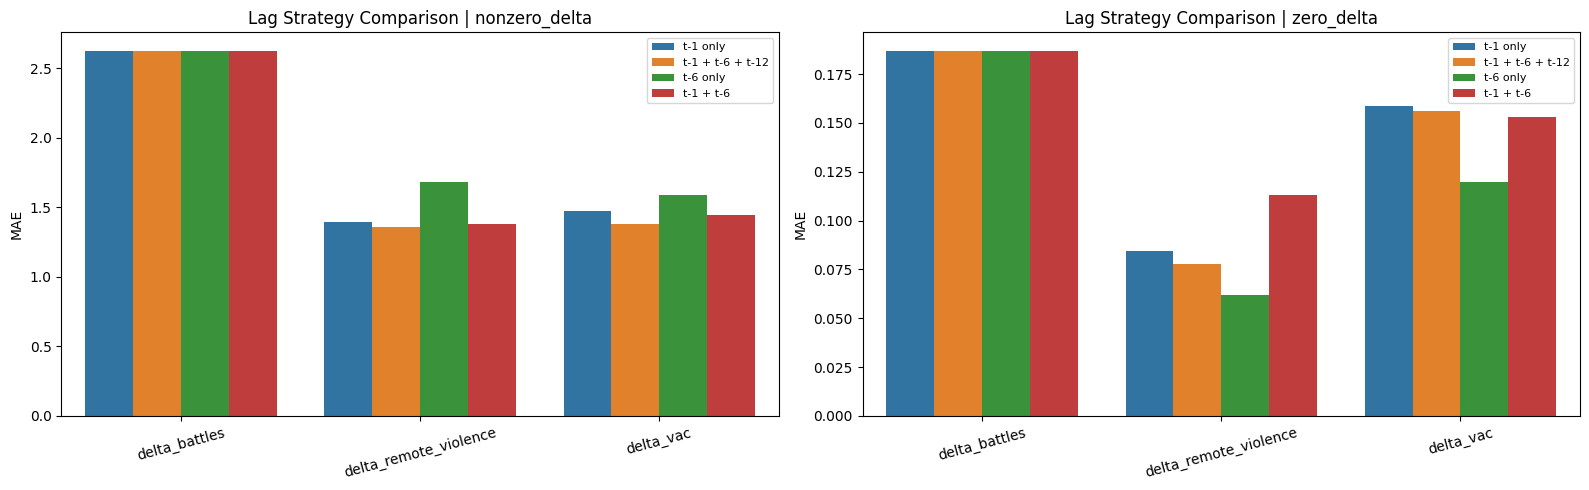

In [23]:
# Combine all summaries including what we already have
all_summaries = pd.concat([
    two_stage_summary[two_stage_summary['model'] == 'TwoStage_CatBoost'][['target', 'delta_group', 'mae']].assign(lag_strategy='t-1 only'),
    per_target_summary.assign(lag_strategy='t-1 + t-6 + t-12'),
    summary_t6_only,
    summary_t1_t6,
], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, group in zip(axes, ['nonzero_delta', 'zero_delta']):
    data = all_summaries[all_summaries['delta_group'] == group]
    sns.barplot(data=data, x='target', y='mae', hue='lag_strategy', ax=ax)
    ax.set_title(f'Lag Strategy Comparison | {group}')
    ax.set_xlabel('')
    ax.set_ylabel('MAE')
    ax.tick_params(axis='x', rotation=15)
    ax.legend(title='', fontsize=8)

plt.tight_layout()
plt.show()

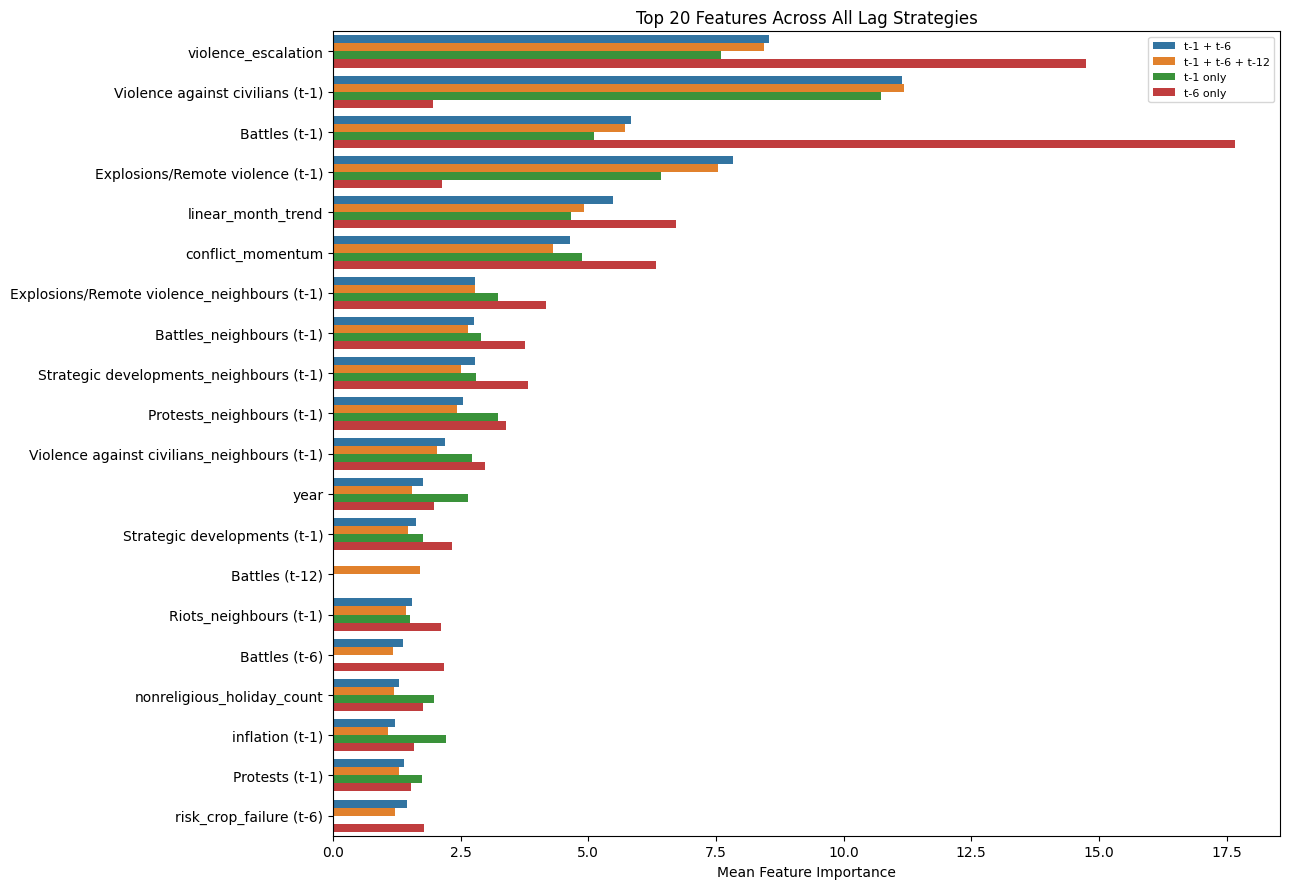

In [24]:
# FI comparison across all strategies
all_fi = pd.concat([
    two_stage_fi_df[['stage', 'feature', 'importance']].assign(lag_strategy='t-1 only'),
    per_target_fi_df[['stage', 'feature', 'importance']].assign(lag_strategy='t-1 + t-6 + t-12'),
    fi_t6_only,
    fi_t1_t6,
], ignore_index=True)

TOP_N = 20

top_features = (
    all_fi.groupby('feature')['importance']
    .mean()
    .sort_values(ascending=False)
    .head(TOP_N)
    .index
)

plot_fi = (
    all_fi[all_fi['feature'].isin(top_features)]
    .groupby(['lag_strategy', 'feature'])['importance']
    .mean()
    .reset_index()
)

order = (
    plot_fi.groupby('feature')['importance']
    .mean()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(13, 9))
sns.barplot(data=plot_fi, y='feature', x='importance', hue='lag_strategy', order=order)
plt.title(f'Top {TOP_N} Features Across All Lag Strategies')
plt.xlabel('Mean Feature Importance')
plt.ylabel('')
plt.legend(title='', fontsize=8)
plt.tight_layout()
plt.show()

## conclusion

Four strategies were tested on 100 regions: t-1 only, t-6 only, t-1+t-6, and t-1+t-6+t-12.

Removing t-1 entirely (t-6 only) hurts performance — when recent conflict lags 
are gone the model over-compensates by leaning on Battles (t-1) as a proxy, 
which is not a clean signal. t-1 carries irreplaceable short-term momentum.

Adding t-6 and t-12 on top of t-1 improves remote violence and VAC on nonzero-delta 
months without hurting battles. Battles behaves differently — extended lags introduce 
noise for this target and t-1 only remains best.

**Final decision:** per-target lag strategy adopted for the pipeline:
- Battles : t-1 only
- Remote violence + VAC : t-1, t-6, t-12

## t-1 Lag Dependency Test

The model heavily relies on t-1 conflict lags (previous month) as its strongest 
predictor. For a 6-month-ahead forecasting tool this is a concern. This test checks whether removing t-1 conflict lags forces the model 
to learn more meaningful patterns from structural features (risk scores, economic signals, seasonal trends) and whether that improves directional accuracy. The ability to correctly predict whether conflict will escalate, de-escalate, or stay stable. We evaluate on **MAE, RMSE, and directional accuracy** to get a complete picture.
MAE is not the ideal metric for this evaluation. It rewards conservative predictions, a model that simply copies last month's count gets a low MAE because most months show little change (86-92% zero-delta). This means a model can look good on MAE while being completely useless for early warning, since it is just extrapolating 
recent trends rather than detecting where conflict is heading.
Directional accuracy measures something more meaningful for conflict forecasting: 
did the model correctly predict whether conflict would escalate, de-escalate, or 
stay stable? 

In [28]:
# Directional accuracy helper
def directional_accuracy(y_true, y_pred):
    correct = 0
    for actual, pred in zip(y_true, y_pred):
        if actual == 0 and pred == 0:
            correct += 1
        elif actual > 0 and pred > 0:
            correct += 1
        elif actual < 0 and pred < 0:
            correct += 1
    return correct / len(y_true)


# Feature sets for the two variants
# Variant 1: current best (per-target lags, t-1 included)
variant1_feature_cols = {
    'delta_battles':         baseline_feature_cols,
    'delta_remote_violence': extended_feature_cols,
    'delta_vac':             extended_feature_cols,
}

# Variant 2: drop t-1 conflict lags, keep t-6 and t-12
conflict_no_t1 = [
    f'{c} (t-6)'  for c in CONFLICT_COLS_TO_LAG if f'{c} (t-6)'  in model_data.columns
] + [
    f'{c} (t-12)' for c in CONFLICT_COLS_TO_LAG if f'{c} (t-12)' in model_data.columns
]

risk_no_t1 = (
    [c for c in risk_features if '(t-1)' not in c]
    + [f'{c} (t-6)'  for c in RISK_COLS_TO_LAG if f'{c} (t-6)'  in model_data.columns]
    + [f'{c} (t-12)' for c in RISK_COLS_TO_LAG if f'{c} (t-12)' in model_data.columns]
)

no_t1_feature_cols = list(dict.fromkeys(
    conflict_no_t1
    + neighbor_features
    + time_features
    + worldbank_lag_features
    + religion_features
    + holiday_current_features
    + holiday_interaction_current
    + wbd_engineered_features
    + risk_no_t1
))

variant2_feature_cols = {
    'delta_battles':         no_t1_feature_cols,
    'delta_remote_violence': no_t1_feature_cols,
    'delta_vac':             no_t1_feature_cols,
}

print(f"Variant 1 battles features:    {len(baseline_feature_cols)}")
print(f"Variant 1 remote/vac features: {len(extended_feature_cols)}")
print(f"Variant 2 features (all):      {len(no_t1_feature_cols)}")

Variant 1 battles features:    80
Variant 1 remote/vac features: 100
Variant 2 features (all):      85


In [29]:
variant_rows = []

for variant_name, feat_col_map in [
    ('With t-1', variant1_feature_cols),
    ('Without t-1', variant2_feature_cols),
]:
    print(f"\nRunning: {variant_name}")

    for i, region in enumerate(VALID_REGIONS[:100], start=1):
        if i % 25 == 0:
            print(f"  {i}/100 regions")

        region_data = model_data.loc[region].sort_index()
        train_data, test_data = split_region_data(region_data)
        weights_full = train_data['importance_weight'] if 'importance_weight' in train_data.columns else None

        for target in DELTA_TARGETS:
            feat_cols = feat_col_map[target]

            train_pair = train_data[feat_cols + [target]].dropna(subset=[target])
            test_pair  = test_data[feat_cols  + [target]].dropna(subset=[target])

            if len(train_pair) == 0 or len(test_pair) == 0:
                continue

            y_train = train_pair[target]
            y_test  = test_pair[target]

            y_bin = (y_train != 0).astype(int)
            if y_bin.nunique() <= 1:
                continue

            weights = weights_full.loc[train_pair.index] if weights_full is not None else None

            X_train, X_test, cat_cols = prepare_catboost_inputs(
                train_pair, test_pair, feat_cols
            )

            fit_kw = {}
            if cat_cols: fit_kw['cat_features'] = cat_cols
            if weights is not None: fit_kw['sample_weight'] = weights.values

            # Stage 1
            clf = CatBoostClassifier(
                iterations=300, learning_rate=0.05, depth=4,
                random_seed=RANDOM_STATE, verbose=0,
            )
            clf.fit(X_train, y_bin, **fit_kw)
            change_flag = (clf.predict_proba(X_test)[:, 1] >= 0.5).astype(int)

            # Stage 2
            nonzero_mask = y_train != 0
            if nonzero_mask.sum() < 5:
                stage2_pred = np.zeros(len(y_test))
            else:
                reg = CatBoostRegressor(
                    iterations=300, learning_rate=0.05, depth=4,
                    random_seed=RANDOM_STATE, verbose=0,
                )
                reg_kw = {k: v for k, v in fit_kw.items() if k != 'sample_weight'}
                if weights is not None: reg_kw['sample_weight'] = weights.loc[nonzero_mask].values
                reg.fit(X_train.loc[nonzero_mask], y_train.loc[nonzero_mask], **reg_kw)
                stage2_pred = reg.predict(X_test)

            final_pred = change_flag * stage2_pred

            for actual, pred in zip(y_test.values, final_pred):
                variant_rows.append({
                    'variant': variant_name,
                    'target': target,
                    'delta_group': 'nonzero_delta' if actual != 0 else 'zero_delta',
                    'actual': actual,
                    'pred': pred,
                    'abs_error': abs(actual - pred),
                    'sq_error': (actual - pred) ** 2,
                    'correct_direction': int(
                        (actual == 0 and pred == 0) or
                        (actual > 0 and pred > 0) or
                        (actual < 0 and pred < 0)
                    ),
                })

variant_df = pd.DataFrame(variant_rows)
print("\nDone.")


Running: With t-1
  25/100 regions
  50/100 regions
  75/100 regions
  100/100 regions

Running: Without t-1
  25/100 regions
  50/100 regions
  75/100 regions
  100/100 regions

Done.


In [30]:
# Summary table
variant_summary = (
    variant_df
    .groupby(['variant', 'target'])
    .agg(
        mae=('abs_error', 'mean'),
        rmse=('sq_error', lambda x: np.sqrt(x.mean())),
        directional_accuracy=('correct_direction', 'mean'),
    )
    .round(4)
    .reset_index()
)

print(variant_summary.to_string(index=False))

    variant                target    mae   rmse  directional_accuracy
   With t-1         delta_battles 0.9761 2.5733                0.7033
   With t-1 delta_remote_violence 0.3027 0.8069                0.8304
   With t-1             delta_vac 0.4251 0.9429                0.7969
Without t-1         delta_battles 1.0000 2.5548                0.7033
Without t-1 delta_remote_violence 0.3444 0.8873                0.7857
Without t-1             delta_vac 0.4433 1.0566                0.7760


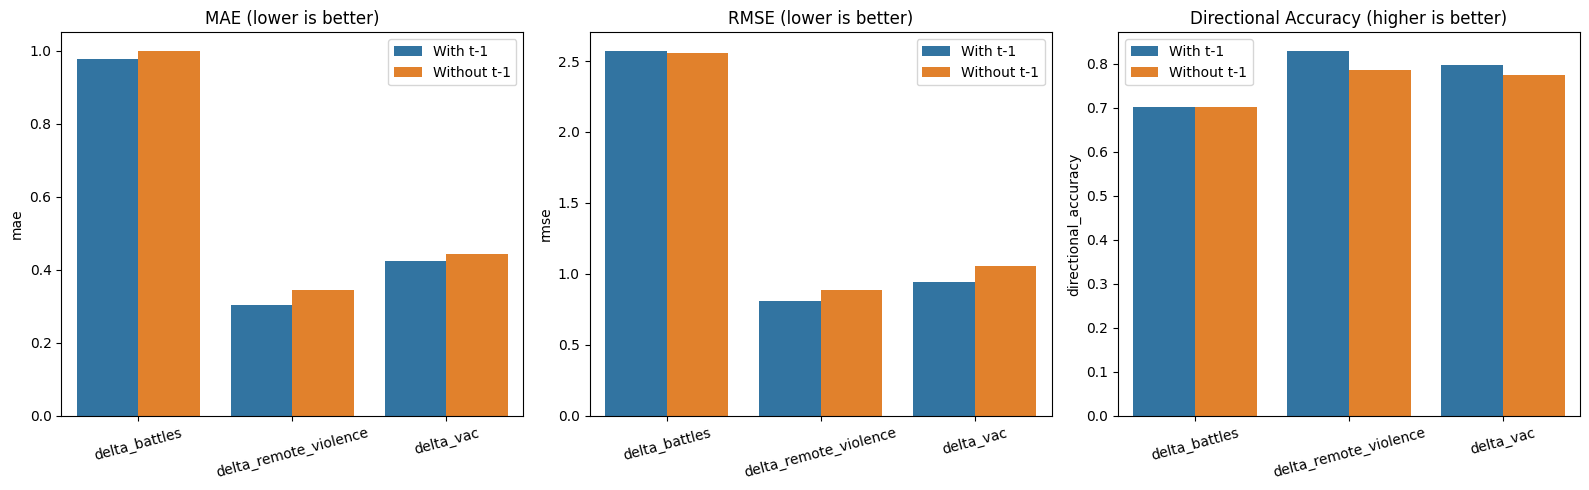

In [31]:
# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = [
    ('mae', 'MAE (lower is better)'),
    ('rmse', 'RMSE (lower is better)'),
    ('directional_accuracy', 'Directional Accuracy (higher is better)'),
]

for ax, (metric, title) in zip(axes, metrics):
    sns.barplot(
        data=variant_summary,
        x='target', y=metric, hue='variant', ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)
    ax.legend(title='')

plt.tight_layout()
plt.show()

In [34]:
no_t1_fi_records = []

for i, region in enumerate(VALID_REGIONS[:100], start=1):
    if i % 25 == 0:
        print(f"{i}/100 regions")

    region_data = model_data.loc[region].sort_index()
    train_data, test_data = split_region_data(region_data)
    weights_full = train_data['importance_weight'] if 'importance_weight' in train_data.columns else None

    for target in DELTA_TARGETS:
        feat_cols = variant2_feature_cols[target]

        train_pair = train_data[feat_cols + [target]].dropna(subset=[target])
        test_pair  = test_data[feat_cols  + [target]].dropna(subset=[target])

        if len(train_pair) == 0 or len(test_pair) == 0:
            continue

        y_train = train_pair[target]
        y_test  = test_pair[target]

        y_bin = (y_train != 0).astype(int)
        if y_bin.nunique() <= 1:
            continue

        weights = weights_full.loc[train_pair.index] if weights_full is not None else None
        X_train, X_test, cat_cols = prepare_catboost_inputs(train_pair, test_pair, feat_cols)

        fit_kw = {}
        if cat_cols: fit_kw['cat_features'] = cat_cols
        if weights is not None: fit_kw['sample_weight'] = weights.values

        # Stage 1
        clf = CatBoostClassifier(
            iterations=300, learning_rate=0.05, depth=4,
            random_seed=RANDOM_STATE, verbose=0,
        )
        clf.fit(X_train, y_bin, **fit_kw)

        no_t1_fi_records.append(pd.DataFrame({
            'stage': 'Stage 1 - classifier',
            'target': target,
            'feature': feat_cols,
            'importance': clf.feature_importances_,
        }))

        # Stage 2
        nonzero_mask = y_train != 0
        if nonzero_mask.sum() < 5:
            continue

        reg = CatBoostRegressor(
            iterations=300, learning_rate=0.05, depth=4,
            random_seed=RANDOM_STATE, verbose=0,
        )
        reg_kw = {k: v for k, v in fit_kw.items() if k != 'sample_weight'}
        if weights is not None: reg_kw['sample_weight'] = weights.loc[nonzero_mask].values
        reg.fit(X_train.loc[nonzero_mask], y_train.loc[nonzero_mask], **reg_kw)

        no_t1_fi_records.append(pd.DataFrame({
            'stage': 'Stage 2 - regressor',
            'target': target,
            'feature': feat_cols,
            'importance': reg.feature_importances_,
        }))

no_t1_fi_df = pd.concat(no_t1_fi_records, ignore_index=True)
print("Done.")

25/100 regions
50/100 regions
75/100 regions
100/100 regions
Done.


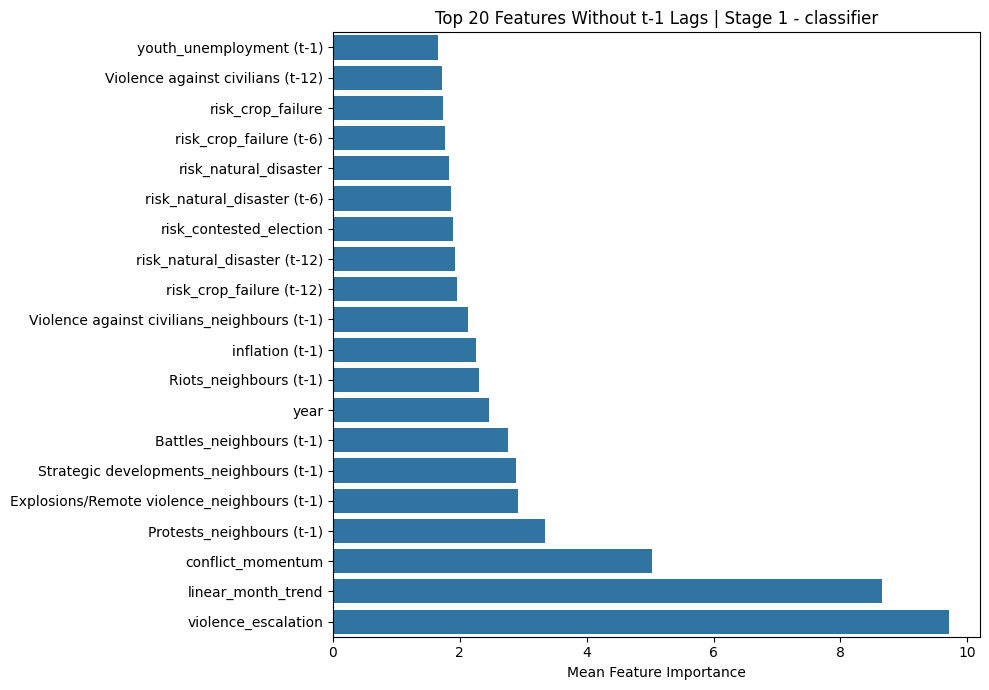

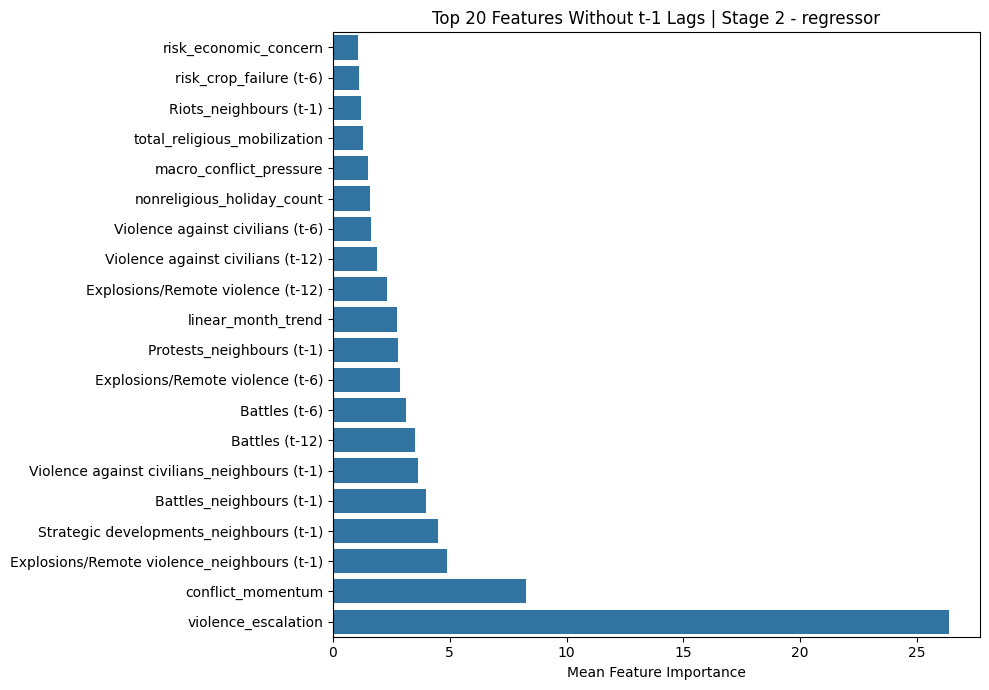

In [35]:
TOP_N = 20

for stage in ['Stage 1 - classifier', 'Stage 2 - regressor']:
    fi_stage = no_t1_fi_df[no_t1_fi_df['stage'] == stage]

    top_features = (
        fi_stage.groupby('feature')['importance']
        .mean()
        .sort_values(ascending=False)
        .head(TOP_N)
        .index
    )

    plot_fi = (
        fi_stage[fi_stage['feature'].isin(top_features)]
        .groupby('feature')['importance']
        .mean()
        .reset_index()
        .sort_values('importance', ascending=True)
    )

    plt.figure(figsize=(10, 7))
    sns.barplot(data=plot_fi, y='feature', x='importance')
    plt.title(f'Top {TOP_N} Features Without t-1 Lags | {stage}')
    plt.xlabel('Mean Feature Importance')
    plt.ylabel('')
    plt.tight_layout()
    plt.show()

## Importance weight consistancy check

In [25]:
print(model_data['importance_weight'].describe())
print(model_data['importance_weight'].head(10))

count    278820.000000
mean          0.225293
std           0.256881
min           0.011679
25%           0.035084
50%           0.108101
75%           0.332871
max           1.000000
Name: importance_weight, dtype: float64
matched_admin1_id  month_year
ABW - Aruba        2018-01       0.011679
                   2018-02       0.012277
                   2018-03       0.012907
                   2018-04       0.013569
                   2018-05       0.014264
                   2018-06       0.014996
                   2018-07       0.015764
                   2018-08       0.016573
                   2018-09       0.017422
                   2018-10       0.018316
Name: importance_weight, dtype: float64


In [27]:
region = VALID_REGIONS[0]
region_data = model_data.loc[region].sort_index()
train_data, _ = split_region_data(region_data)

target = 'delta_battles'
train_pair = train_data[baseline_feature_cols + [target]].dropna(subset=[target])

y_train = train_pair[target]
weights = train_data['importance_weight'].loc[train_pair.index]
nonzero_mask = y_train != 0

X_train, _, _ = prepare_catboost_inputs(train_pair, train_pair, baseline_feature_cols)

# Check alignment after subsetting
print("Indices aligned (full):   ", X_train.index.equals(weights.index))
print("Indices aligned (nonzero):", X_train.loc[nonzero_mask].index.equals(weights.loc[nonzero_mask].index))
print("X nonzero shape:", X_train.loc[nonzero_mask].shape)
print("weights nonzero shape:", weights.loc[nonzero_mask].shape)

Indices aligned (full):    True
Indices aligned (nonzero): True
X nonzero shape: (74, 80)
weights nonzero shape: (74,)


## Recency Weight Verification
just a bug check: `importance_weight` indices stay correctly aligned after subsetting 
to nonzero-delta rows in Stage 2.

 ## NaN verification : raw NaN vs fillna(0)

In [36]:
nan_rows = []

for variant_name, use_fillna in [('Raw NaN', False), ('fillna(0)', True)]:
    print(f"Running: {variant_name}")

    for i, region in enumerate(VALID_REGIONS[:50], start=1):
        region_data = model_data.loc[region].sort_index()
        train_data, test_data = split_region_data(region_data)
        weights_full = train_data['importance_weight'] if 'importance_weight' in train_data.columns else None

        for target in DELTA_TARGETS:
            feat_cols = per_target_feature_cols[target]

            train_pair = train_data[feat_cols + [target]].dropna(subset=[target])
            test_pair  = test_data[feat_cols  + [target]].dropna(subset=[target])

            if len(train_pair) == 0 or len(test_pair) == 0:
                continue

            y_train = train_pair[target]
            y_test  = test_pair[target]

            y_bin = (y_train != 0).astype(int)
            if y_bin.nunique() <= 1:
                continue

            weights = weights_full.loc[train_pair.index] if weights_full is not None else None

            # Apply fillna only for that variant
            if use_fillna:
                num_cols = train_pair.select_dtypes(include=['number']).columns
                train_pair = train_pair.copy()
                test_pair  = test_pair.copy()
                train_pair[num_cols] = train_pair[num_cols].fillna(0)
                test_pair[num_cols]  = test_pair[num_cols].fillna(0)

            X_train, X_test, cat_cols = prepare_catboost_inputs(
                train_pair, test_pair, feat_cols
            )

            fit_kw = {}
            if cat_cols: fit_kw['cat_features'] = cat_cols
            if weights is not None: fit_kw['sample_weight'] = weights.values

            clf = CatBoostClassifier(iterations=300, learning_rate=0.05, depth=4, random_seed=RANDOM_STATE, verbose=0)
            clf.fit(X_train, y_bin, **fit_kw)
            change_flag = (clf.predict_proba(X_test)[:, 1] >= 0.5).astype(int)

            nonzero_mask = y_train != 0
            if nonzero_mask.sum() < 5:
                stage2_pred = np.zeros(len(y_test))
            else:
                reg = CatBoostRegressor(iterations=300, learning_rate=0.05, depth=4, random_seed=RANDOM_STATE, verbose=0)
                reg_kw = {k: v for k, v in fit_kw.items() if k != 'sample_weight'}
                if weights is not None: reg_kw['sample_weight'] = weights.loc[nonzero_mask].values
                reg.fit(X_train.loc[nonzero_mask], y_train.loc[nonzero_mask], **reg_kw)
                stage2_pred = reg.predict(X_test)

            final_pred = change_flag * stage2_pred

            for actual, pred in zip(y_test.values, final_pred):
                nan_rows.append({
                    'variant': variant_name,
                    'target': target,
                    'abs_error': abs(actual - pred),
                    'sq_error': (actual - pred) ** 2,
                    'correct_direction': int(
                        (actual == 0 and pred == 0) or
                        (actual > 0 and pred > 0) or
                        (actual < 0 and pred < 0)
                    ),
                })

nan_df = pd.DataFrame(nan_rows)

nan_summary = (
    nan_df
    .groupby(['variant', 'target'])
    .agg(
        mae=('abs_error', 'mean'),
        rmse=('sq_error', lambda x: np.sqrt(x.mean())),
        directional_accuracy=('correct_direction', 'mean'),
    )
    .round(4)
    .reset_index()
)

print(nan_summary.to_string(index=False))

Running: Raw NaN
Running: fillna(0)
  variant                target    mae   rmse  directional_accuracy
  Raw NaN         delta_battles 0.7963 1.4521                0.6396
  Raw NaN delta_remote_violence 0.4205 0.9600                0.7692
  Raw NaN             delta_vac 0.7851 1.2959                0.6433
fillna(0)         delta_battles 0.8553 1.5589                0.6351
fillna(0) delta_remote_violence 0.4332 0.9460                0.7863
fillna(0)             delta_vac 0.7884 1.3254                0.6467


## conclusion

 CatBoost native NaN handling (raw NaN) outperforms fillna(0) on MAE 
and RMSE across all three targets. Zero-filling distorts the signal by replacing 
"missing data" with "zero value" which are not the same thing. Current setup 
(raw NaN passthrough) is correct and is kept.

## conflict intensity segmentation 
all regions should not treat same! 

In [38]:
RAW_TARGET_MAP = {
    'delta_battles':         'Battles',
    'delta_remote_violence':  'Explosions/Remote violence',
    'delta_vac':             'Violence against civilians',
}

TIER_THRESHOLDS = {'quiet': 1, 'moderate': 10}

def assign_tier(mean_val):
    if mean_val < TIER_THRESHOLDS['quiet']:
        return 'quiet (<1)'
    elif mean_val <= TIER_THRESHOLDS['moderate']:
        return 'moderate (1-10)'
    else:
        return 'active (>10)'

region_tiers = {}
for delta_col, raw_col in RAW_TARGET_MAP.items():
    region_means = (
        model_data.groupby(level='matched_admin1_id')[raw_col]
        .mean()
    )
    region_tiers[delta_col] = region_means.apply(assign_tier)


for delta_col, tiers in region_tiers.items():
    print(f"\n{delta_col}:")
    print(tiers.value_counts().sort_index())


delta_battles:
Battles
active (>10)         88
moderate (1-10)     259
quiet (<1)         2750
Name: count, dtype: int64

delta_remote_violence:
Explosions/Remote violence
active (>10)         60
moderate (1-10)     127
quiet (<1)         2910
Name: count, dtype: int64

delta_vac:
Violence against civilians
active (>10)         67
moderate (1-10)     333
quiet (<1)         2697
Name: count, dtype: int64


In [39]:
# Also collect persistence baseline for comparison

intensity_rows = []

for i, region in enumerate(VALID_REGIONS[:100], start=1):
    if i % 25 == 0:
        print(f"{i}/100 regions")

    region_data = model_data.loc[region].sort_index()
    train_data, test_data = split_region_data(region_data)
    weights_full = train_data['importance_weight'] if 'importance_weight' in train_data.columns else None

    for target in DELTA_TARGETS:
        feat_cols = per_target_feature_cols[target]
        tier = region_tiers[target].get(region, 'unknown')

        train_pair = train_data[feat_cols + [target]].dropna(subset=[target])
        test_pair  = test_data[feat_cols  + [target]].dropna(subset=[target])

        if len(train_pair) == 0 or len(test_pair) == 0:
            continue

        y_train = train_pair[target]
        y_test  = test_pair[target]

        y_bin = (y_train != 0).astype(int)
        if y_bin.nunique() <= 1:
            continue

        weights = weights_full.loc[train_pair.index] if weights_full is not None else None
        X_train, X_test, cat_cols = prepare_catboost_inputs(train_pair, test_pair, feat_cols)

        fit_kw = {}
        if cat_cols: fit_kw['cat_features'] = cat_cols
        if weights is not None: fit_kw['sample_weight'] = weights.values

        # Stage 1
        clf = CatBoostClassifier(
            iterations=300, learning_rate=0.05, depth=4,
            random_seed=RANDOM_STATE, verbose=0,
        )
        clf.fit(X_train, y_bin, **fit_kw)
        change_flag = (clf.predict_proba(X_test)[:, 1] >= 0.5).astype(int)

        # Stage 2
        nonzero_mask = y_train != 0
        if nonzero_mask.sum() < 5:
            stage2_pred = np.zeros(len(y_test))
        else:
            reg = CatBoostRegressor(
                iterations=300, learning_rate=0.05, depth=4,
                random_seed=RANDOM_STATE, verbose=0,
            )
            reg_kw = {k: v for k, v in fit_kw.items() if k != 'sample_weight'}
            if weights is not None: reg_kw['sample_weight'] = weights.loc[nonzero_mask].values
            reg.fit(X_train.loc[nonzero_mask], y_train.loc[nonzero_mask], **reg_kw)
            stage2_pred = reg.predict(X_test)

        final_pred = change_flag * stage2_pred

        for actual, pred in zip(y_test.values, final_pred):
            # Two-stage model
            intensity_rows.append({
                'region': region,
                'target': target,
                'tier': tier,
                'model': 'TwoStage_CatBoost',
                'actual': actual,
                'pred': pred,
                'abs_error': abs(actual - pred),
                'sq_error': (actual - pred) ** 2,
                'correct_direction': int(
                    (actual == 0 and pred == 0) or
                    (actual > 0 and pred > 0) or
                    (actual < 0 and pred < 0)
                ),
            })

            # Persistence baseline
            intensity_rows.append({
                'region': region,
                'target': target,
                'tier': tier,
                'model': 'Persistence',
                'actual': actual,
                'pred': 0.0,
                'abs_error': abs(actual),
                'sq_error': actual ** 2,
                'correct_direction': int(actual == 0),
            })

intensity_df = pd.DataFrame(intensity_rows)
print("Done.")

25/100 regions
50/100 regions
75/100 regions
100/100 regions
Done.


In [42]:
intensity_summary = (
    intensity_df
    .groupby(['target', 'tier', 'model'])
    .agg(
        mae=('abs_error', 'mean'),
        rmse=('sq_error', lambda x: np.sqrt(x.mean())),
        directional_accuracy=('correct_direction', 'mean'),
        n_regions=('region', 'nunique'),
    )
    .round(4)
    .reset_index()
)

# Pivot for clean comparison
intensity_pivot = intensity_summary.pivot_table(
    index=['target', 'tier'],
    columns='model',
    values=['mae', 'rmse', 'directional_accuracy']
).round(4)

intensity_pivot['mae_improvement_pct'] = (
    (intensity_pivot['mae']['Persistence'] - intensity_pivot['mae']['TwoStage_CatBoost'])
    / intensity_pivot['mae']['Persistence'] * 100
).round(2)

print(intensity_pivot.to_string())

                                      directional_accuracy                           mae                          rmse                   mae_improvement_pct
model                                          Persistence TwoStage_CatBoost Persistence TwoStage_CatBoost Persistence TwoStage_CatBoost                    
target                tier                                                                                                                                  
delta_battles         active (>10)                  0.5556            0.6111      0.9333            1.0852      1.8559            1.9886              -16.28
                      moderate (1-10)               0.5985            0.5985      1.3333            1.4465      3.6118            3.5084               -8.49
                      quiet (<1)                    0.9487            0.9872      0.1026            0.0542      0.4529            0.2736               47.17
delta_remote_violence active (>10)                  0.8750

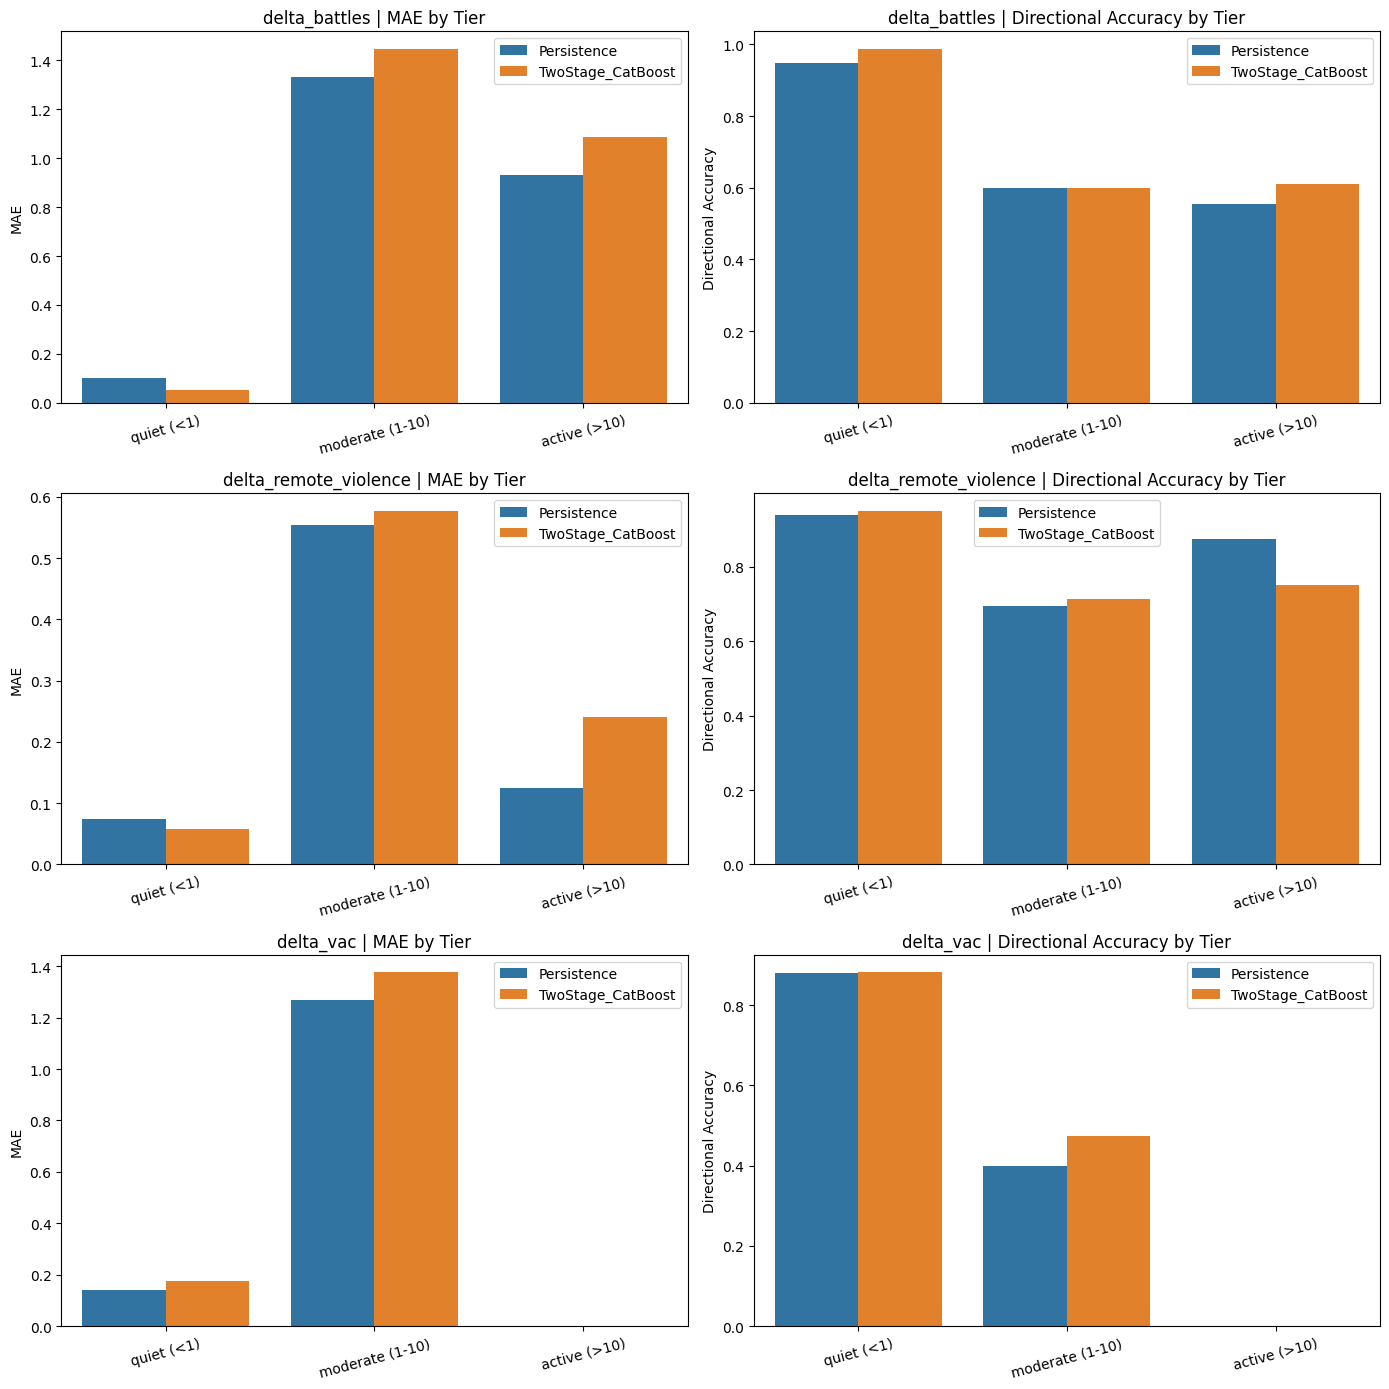

In [43]:
TIER_ORDER = ['quiet (<1)', 'moderate (1-10)', 'active (>10)']

fig, axes = plt.subplots(3, 2, figsize=(14, 14))

for row, target in enumerate(DELTA_TARGETS):
    target_df = intensity_summary[intensity_summary['target'] == target].copy()
    target_df['tier'] = pd.Categorical(target_df['tier'], categories=TIER_ORDER, ordered=True)
    target_df = target_df.sort_values('tier')

    # MAE
    sns.barplot(
        data=target_df, x='tier', y='mae', hue='model',
        ax=axes[row][0]
    )
    axes[row][0].set_title(f'{target} | MAE by Tier')
    axes[row][0].set_xlabel('')
    axes[row][0].set_ylabel('MAE')
    axes[row][0].legend(title='')
    axes[row][0].tick_params(axis='x', rotation=15)

    # Directional accuracy
    sns.barplot(
        data=target_df, x='tier', y='directional_accuracy', hue='model',
        ax=axes[row][1]
    )
    axes[row][1].set_title(f'{target} | Directional Accuracy by Tier')
    axes[row][1].set_xlabel('')
    axes[row][1].set_ylabel('Directional Accuracy')
    axes[row][1].legend(title='')
    axes[row][1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## conclusion:
Regions were split into three tiers per target independently quiet (<1 mean monthly count), moderate (1-10), and active (>10) and evaluated against persistence baseline.

the model adds clearest value in active remote violence regions (92% MAE improvement over persistence) and quiet battles regions (early conflict onset detection). For moderate and active battles and VAC tiers, persistence is competitive on MAE but the model wins on directional accuracy. 
Aggregate MAE across all regions masks both the wins and losses. The model is most useful for remote violence in high-conflict zones and least reliable for battles in moderate conflict areas.

## top 10 region for evaluation :

In [46]:
# Top-10 highest activity regions — mutual comparison ground with Giray

test_period_activity = (
    model_data
    .groupby(level='matched_admin1_id')[['Battles', 'Explosions/Remote violence', 'Violence against civilians']]
    .apply(lambda x: x.iloc[-6:].sum().sum())
)

top10_regions = (
    test_period_activity
    .sort_values(ascending=False)
    .head(10)
    .index.tolist()
)

print("Top 10 highest activity regions:")
for r in top10_regions:
    print(f"  {r}: {test_period_activity[r]:.0f} total events in test period")

# Run two-stage on top-10
top10_rows = []

for region in top10_regions:
    region_data = model_data.loc[region].sort_index()
    train_data, test_data = split_region_data(region_data)
    weights_full = train_data['importance_weight'] if 'importance_weight' in train_data.columns else None

    for target in DELTA_TARGETS:
        feat_cols = per_target_feature_cols[target]
        train_pair = train_data[feat_cols + [target]].dropna(subset=[target])
        test_pair  = test_data[feat_cols  + [target]].dropna(subset=[target])

        if len(train_pair) == 0 or len(test_pair) == 0:
            continue

        y_train = train_pair[target]
        y_test  = test_pair[target]
        y_bin   = (y_train != 0).astype(int)

        if y_bin.nunique() <= 1:
            continue

        weights = weights_full.loc[train_pair.index] if weights_full is not None else None
        X_train, X_test, cat_cols = prepare_catboost_inputs(train_pair, test_pair, feat_cols)

        fit_kw = {}
        if cat_cols: fit_kw['cat_features'] = cat_cols
        if weights is not None: fit_kw['sample_weight'] = weights.values

        clf = CatBoostClassifier(iterations=300, learning_rate=0.05, depth=4, random_seed=RANDOM_STATE, verbose=0)
        clf.fit(X_train, y_bin, **fit_kw)
        change_flag = (clf.predict_proba(X_test)[:, 1] >= 0.5).astype(int)

        nonzero_mask = y_train != 0
        if nonzero_mask.sum() < 5:
            stage2_pred = np.zeros(len(y_test))
        else:
            reg = CatBoostRegressor(iterations=300, learning_rate=0.05, depth=4, random_seed=RANDOM_STATE, verbose=0)
            reg_kw = {k: v for k, v in fit_kw.items() if k != 'sample_weight'}
            if weights is not None: reg_kw['sample_weight'] = weights.loc[nonzero_mask].values
            reg.fit(X_train.loc[nonzero_mask], y_train.loc[nonzero_mask], **reg_kw)
            stage2_pred = reg.predict(X_test)

        final_pred = change_flag * stage2_pred

        raw_col = RAW_TARGET_MAP[target]
        y_prev = test_data[raw_col].shift(1).fillna(train_data[raw_col].iloc[-1])

        for j, (actual, pred) in enumerate(zip(y_test.values, final_pred)):
            top10_rows.append({
                'region': region,
                'target': target,
                'actual_delta': actual,
                'pred_delta': pred,
                'y_prev': y_prev.iloc[j],
                'abs_error_delta': abs(actual - pred),
            })

top10_df = pd.DataFrame(top10_rows)
top10_df['predicted_count'] = (top10_df['y_prev'] + top10_df['pred_delta']).clip(lower=0)
top10_df['actual_count']    = top10_df['y_prev'] + top10_df['actual_delta']
top10_df['abs_error_count'] = abs(top10_df['actual_count'] - top10_df['predicted_count'])

top10_summary = (
    top10_df
    .groupby('target')['abs_error_count']
    .mean()
    .round(3)
)

print("\nCAST+ MAE on top-10 regions:")
print(top10_summary)
print(f"\nOverall MAE top-10: {top10_summary.mean():.3f}")

Top 10 highest activity regions:
  UKR - Donetsk: 11045 total events in test period
  UKR - Sumy: 6740 total events in test period
  RUS - Belgorod: 5643 total events in test period
  UKR - Kherson: 4739 total events in test period
  PSX - Gaza: 3723 total events in test period
  UKR - Kharkiv: 3385 total events in test period
  UKR - Zaporizhzhia: 2478 total events in test period
  RUS - Kursk: 2157 total events in test period
  UKR - Chernihiv: 1942 total events in test period
  PSX - West Bank: 1434 total events in test period

CAST+ MAE on top-10 regions:
target
delta_battles             29.615
delta_remote_violence    120.414
delta_vac                  6.842
Name: abs_error_count, dtype: float64

Overall MAE top-10: 52.290


In [47]:
# ── FAIR COMPARISON WITH GIRAY ────────────────────────────────────────────────
# Run CAST baseline (RF, ACLED only) on same top-10 regions
# Then compare CAST+ two-stage on same top-10 regions vs same baseline

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

ACLED_ONLY_FEATURES = [
    'Battles (t-1)', 'Explosions/Remote violence (t-1)', 'Protests (t-1)',
    'Riots (t-1)', 'Strategic developments (t-1)',
    'Violence against civilians (t-1)',
    'Excessive force against protesters (t-1)', 'Agreement (t-1)',
    'Explosions/Remote violence_neighbours (t-1)',
    'Strategic developments_neighbours (t-1)', 'Protests_neighbours (t-1)',
    'Violence against civilians_neighbours (t-1)',
    'Battles_neighbours (t-1)', 'Riots_neighbours (t-1)',
    'linear_month_trend', 'year',
    'month_2', 'month_3', 'month_4', 'month_5', 'month_6',
    'month_7', 'month_8', 'month_9', 'month_10', 'month_11', 'month_12',
    'quarter_2', 'quarter_3', 'quarter_4',
]

RAW_TARGETS = {
    'delta_battles':         'Battles',
    'delta_remote_violence': 'Explosions/Remote violence',
    'delta_vac':             'Violence against civilians',
}

baseline_top10_rows = []

for region in top10_regions:
    region_data = model_data.loc[region].sort_index()
    train_data, test_data = split_region_data(region_data)

    weights = train_data['importance_weight']

    # Fill NaN for RF
    X_train = train_data[ACLED_ONLY_FEATURES].fillna(0)
    X_test  = test_data[ACLED_ONLY_FEATURES].fillna(0)

    for raw_target in ['Battles', 'Explosions/Remote violence', 'Violence against civilians']:
        y_train = train_data[raw_target]
        y_test  = test_data[raw_target]

        if y_train.nunique() <= 1:
            continue

        rf = RandomForestRegressor(n_estimators=100, random_state=42)
        rf.fit(X_train, y_train, sample_weight=weights.values)
        y_pred = np.clip(rf.predict(X_test), 0, None)

        mae = mean_absolute_error(y_test, y_pred)

        baseline_top10_rows.append({
            'region': region,
            'target': raw_target,
            'mae': mae,
            'mean_actual': y_test.mean(),
        })

baseline_top10_df = pd.DataFrame(baseline_top10_rows)

baseline_top10_summary = (
    baseline_top10_df
    .groupby('target')['mae']
    .mean()
    .round(3)
)

print("CAST Baseline (RF, ACLED only) on top-10 regions:")
print(baseline_top10_summary)
print(f"\nOverall MAE: {baseline_top10_summary.mean():.3f}")

# Now compare with CAST+ top-10 results
castplus_top10_summary = (
    top10_df
    .groupby('target')['abs_error_count']
    .mean()
    .round(3)
)

# Map target names to match
target_map = {
    'Battles': 'delta_battles',
    'Explosions/Remote violence': 'delta_remote_violence',
    'Violence against civilians': 'delta_vac',
}
baseline_top10_summary.index = baseline_top10_summary.index.map(target_map)

print("\n" + "=" * 60)
print("FAIR COMPARISON — TOP-10 REGIONS")
print("=" * 60)

comparison = pd.DataFrame({
    'CAST_baseline_MAE': baseline_top10_summary,
    'CAST+_MAE': castplus_top10_summary,
})
comparison['improvement_%'] = (
    (comparison['CAST_baseline_MAE'] - comparison['CAST+_MAE'])
    / comparison['CAST_baseline_MAE'] * 100
).round(2)

print(comparison.to_string())
print(f"\nOverall CAST baseline: {baseline_top10_summary.mean():.3f}")
print(f"Overall CAST+:         {castplus_top10_summary.mean():.3f}")
print(f"Overall improvement:   {((baseline_top10_summary.mean() - castplus_top10_summary.mean()) / baseline_top10_summary.mean() * 100):.1f}%")
print(f"Giray best overall:    53.050")
print(f"Giray improvement:     7.3%")

CAST Baseline (RF, ACLED only) on top-10 regions:
target
Battles                        63.938
Explosions/Remote violence    127.930
Violence against civilians     12.036
Name: mae, dtype: float64

Overall MAE: 67.968

FAIR COMPARISON — TOP-10 REGIONS
                       CAST_baseline_MAE  CAST+_MAE  improvement_%
target                                                            
delta_battles                     63.938     29.615          53.68
delta_remote_violence            127.930    120.414           5.88
delta_vac                         12.036      6.842          43.15

Overall CAST baseline: 67.968
Overall CAST+:         52.290
Overall improvement:   23.1%
Giray best overall:    53.050
Giray improvement:     7.3%
